# Relatório Final - ATP de Preparação e Análise Exploratória de Dados
# Curso de Tecnologia em Big Data e Inteligência Analítica
# Pontifícia Universidade Católica do Paraná (PUCPR)

`Alexandre Kovaleski Rocha` - `alexandre.kovaleski@pucpr.edu.br`

# Introdução

Nesta atividade, vamos trabalhar com um conjunto de dados da empresa Enron. A Enron foi uma das maiores empresas de energia dos Estados Unidos. No seu auge, chegou a valer 65 bilhões de dólares e ela faliu em 24 dias.  A Enron foi fundada em 1985 por Kenneth Lay com a fusão da Houston Natural Gas e da InterNorth. Anos depois, quando Jeffrey Skilling tomou posse, ele estabeleceu um conjunto de diretores que criaram entidades fictícias, relatórios financeiros fracos e contabilidades erradas, que somadas, esconderam bilhões de dólares e projetos fracassados dos investidores. O esquema foi tão complexo que nem mesmo auditorias profissionais foram capazes de identificar estes problemas, e a empresa foi investigada pelo governo norte-americano, incluindo a sua suprema corte. 
A base de dados utilizada na investigação incluía  aproximadamente 500 mil e-mails trocados por empregados da Enron.  Estes e-mails foram obtidos pela comissão regulatória de energia dos Estados Unidos durante sua investigação. A base de dados que vamos utilizar sumariza informações não apenas destes e-mails, mas também de salário e ações da bolsa de valores dos envolvidos. Além disso, os funcionários são divididos em pessoas de interesse (Person of Interest, ou POI), que participaram da fraude; e funcionários que não participaram da fraude, ou não-POIs.

## Dicas

Nesta análise e preparação de dados, nós precisamos ir além de explorações simples. Garanta que toda exploração e análise de dados seja acompanhada de uma análise crítica.

____________________________________________________________________________________________________________________________________

# Importando as bibliotecas

Na célula abaixo, as principais bibliotecas para análise de dados são importadas. Sinta-se a vontade para importar mais bibliotecas de acordo com sua demanda e/ou preferência, contudo, garanta que todos os comandos de `import` sejam feitos na célula abaixo.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# carregue os módulos de sua preferência aqui

In [3]:
np.__version__

'1.26.4'

In [4]:
pd.__version__

'2.2.2'

In [5]:
sns.__version__

'0.13.2'

In [6]:
pd.set_option('display.max_rows', None)

# Mostrar todas as colunas
pd.set_option('display.max_columns', None)

# Se quiser mostrar tudo no console (sem truncar conteúdo)
pd.set_option('display.max_colwidth', None)

____________________________________________________________________________________________________________________________________

# Carregamento de dados

Na célula abaixo é realizado o carregamento da base de dados.
Você **não** deve alterar o código apresentado.

In [4]:
df = pd.read_csv('enron.csv')

In [5]:
## REMOVENDO A LINHA COM NOME "TOTAL", ESTANDO COM VALORES MUITO ACIMA DOS DEMAIS
df_filtered = df[df['name'] != 'TOTAL']

Verificando se a linha do nome TOTAL foi excluída corretamente:

In [9]:
df_filtered.tail(20)

,bonus,deferral_payments,deferred_income,director_fees,email_address,exercised_stock_options,expenses,from_messages,from_poi_to_this_person,from_this_person_to_poi,loan_advances,long_term_incentive,other,poi,restricted_stock,restricted_stock_deferred,salary,shared_receipt_with_poi,to_messages,total_payments,total_stock_value,name
125,700000.0,NaN,NaN,NaN,marty.sunde@enron.com,NaN,NaN,38.0,37.0,13.0,NaN,476451.0,111122.0,False,698920.0,NaN,257486.0,2565.0,2647.0,1545059.0,698920.0,SUNDE MARTIN
126,600000.0,227449.0,NaN,NaN,mitchell.taylor@enron.com,3181250.0,NaN,29.0,0.0,0.0,NaN,NaN,NaN,False,563798.0,NaN,265214.0,300.0,533.0,1092663.0,3745048.0,TAYLOR MITCHELL S
127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,362096.0,False,NaN,NaN,NaN,NaN,NaN,362096.0,NaN,THE TRAVEL AGENCY IN THE PARK
128,NaN,16586.0,NaN,NaN,terence.thorn@enron.com,4452476.0,46145.0,41.0,0.0,0.0,NaN,200000.0,426629.0,False,365320.0,NaN,222093.0,73.0,266.0,911453.0,4817796.0,THORN TERENCE H
129,300000.0,NaN,-575000.0,NaN,elizabeth.tilney@enron.com,591250.0,NaN,19.0,10.0,11.0,NaN,275000.0,152055.0,False,576792.0,NaN,247338.0,379.0,460.0,399393.0,1168042.0,TILNEY ELIZABETH A
131,788750.0,NaN,NaN,NaN,adam.umanoff@enron.com,NaN,53122.0,18.0,12.0,0.0,NaN,NaN,NaN,False,NaN,NaN,288589.0,41.0,111.0,1130461.0,NaN,UMANOFF ADAM S
132,NaN,NaN,-36666.0,36666.0,NaN,NaN,228656.0,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,228656.0,NaN,URQUHART JOHN A
133,NaN,NaN,NaN,109298.0,NaN,NaN,103773.0,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,213071.0,NaN,WAKEHAM JOHN
134,850000.0,NaN,NaN,NaN,rob.walls@enron.com,4346544.0,50936.0,146.0,17.0,0.0,NaN,540751.0,2.0,False,1552453.0,NaN,357091.0,215.0,671.0,1798780.0,5898997.0,WALLS JR ROBERT H
135,NaN,53625.0,NaN,NaN,NaN,1030329.0,33785.0,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,87410.0,1030329.0,WALTERS GARETH W


____________________________________________________________________________________________________________________________________

# Análise descritiva de dados

Nesta etapa, você conduzirá uma análise descritiva da base de dados da Enron.

Para a base de dados como um todo, você deve reportar:
- O número de indivíduos (instâncias) na tabela;
- O número de variáveis descritivas (colunas ou atributos) destes indivíduos;
- O número de pessoas de interesse, isto é, fraudadores (POIs) e não-POIs;

Para cada uma das variáveis numéricas, você deve apresentar:
- Média
- Mediana
- Variância
- Desvio padrão
- Quartis

E para cada uma das variáveis categóricas:
- A moda
- Os valores únicos de cada variável

Além de apresentar estatísticas sobre cada variável da base de dados, a análise a ser conduzida nesta etapa requer uma análise crítica. 
Desta forma, você é convidado a extrair *insights* a partir destas estatísticas, verificando se os valores apresentados condizem ou não com a realidade.
**Lembre-se: todas estas estatísticas devem ser calculadas e apresentadas, de forma legível, no relatório fornecido na descrição da ATP.**


In [10]:
# Informações sobre o dataset

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 145
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   bonus                      81 non-null     float64
 1   deferral_payments          38 non-null     float64
 2   deferred_income            48 non-null     float64
 3   director_fees              16 non-null     float64
 4   email_address              111 non-null    object 
 5   exercised_stock_options    101 non-null    float64
 6   expenses                   94 non-null     float64
 7   from_messages              86 non-null     float64
 8   from_poi_to_this_person    86 non-null     float64
 9   from_this_person_to_poi    86 non-null     float64
 10  loan_advances              3 non-null      float64
 11  long_term_incentive        65 non-null     float64
 12  other                      92 non-null     float64
 13  poi                        145 non-null    bool   
 14 

In [11]:
# O número de indivíduos (instâncias) na tabela

n_instancia = df_filtered['name'].count()
n_instancia

145

In [12]:
# O número de variáveis descritivas (colunas ou atributos) destes indivíduos

n_atributos = df_filtered.shape[1]
n_atributos

22

In [13]:
# O número de pessoas de interesse, isto é, fraudadores (POIs) e não-POIs

n_poi = df_filtered['poi'].value_counts()

poi = {
    True: 'Não-fraudadores',
    False: 'Fraudadores'
}

for valor, total in n_poi.items():
    print(f"{poi[valor]}: {total}")

Fraudadores: 127
Não-fraudadores: 18


### Apresentação de média, mediana, variância, desvio-padrão e quartis das variáveis numéricas

In [14]:
# Selecionando apenas colunas numéricas:

colunas_numericas = df_filtered.select_dtypes(include=['number'])
colunas_numericas.head()

,bonus,deferral_payments,deferred_income,director_fees,exercised_stock_options,expenses,from_messages,from_poi_to_this_person,from_this_person_to_poi,loan_advances,long_term_incentive,other,restricted_stock,restricted_stock_deferred,salary,shared_receipt_with_poi,to_messages,total_payments,total_stock_value
0,4175000.0,2869717.0,-3081055.0,NaN,1729541.0,13868.0,2195.0,47.0,65.0,NaN,304805.0,152.0,126027.0,-126027.0,201955.0,1407.0,2902.0,4484442.0,1729541.0
1,NaN,178980.0,NaN,NaN,257817.0,3486.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,182466.0,257817.0
2,NaN,NaN,-5104.0,NaN,4046157.0,56301.0,29.0,39.0,0.0,NaN,NaN,864523.0,1757552.0,-560222.0,477.0,465.0,566.0,916197.0,5243487.0
3,1200000.0,1295738.0,-1386055.0,NaN,6680544.0,11200.0,NaN,NaN,NaN,NaN,1586055.0,2660303.0,3942714.0,NaN,267102.0,NaN,NaN,5634343.0,10623258.0
4,400000.0,260455.0,-201641.0,NaN,NaN,129142.0,NaN,NaN,NaN,NaN,NaN,69.0,145796.0,-82782.0,239671.0,NaN,NaN,827696.0,63014.0


In [15]:
# Média das colunas numéricas com o comando .mean():

colunas_numericas.mean()

bonus                        1.201773e+06
deferral_payments            8.416025e+05
deferred_income             -5.810498e+05
director_fees                8.982288e+04
exercised_stock_options      2.959559e+06
expenses                     5.419201e+04
from_messages                6.087907e+02
from_poi_to_this_person      6.489535e+01
from_this_person_to_poi      4.123256e+01
loan_advances                2.797500e+07
long_term_incentive          7.464912e+05
other                        4.652767e+05
restricted_stock             1.147424e+06
restricted_stock_deferred    6.218928e+05
salary                       2.840875e+05
shared_receipt_with_poi      1.176465e+03
to_messages                  2.073860e+03
total_payments               2.623421e+06
total_stock_value            3.352073e+06
dtype: float64

In [16]:
# Mediana das colunas numéricas com o comando .median():

colunas_numericas.median()

bonus                         750000.0
deferral_payments             221063.5
deferred_income              -151927.0
director_fees                 106164.5
exercised_stock_options      1297049.0
expenses                       46547.5
from_messages                     41.0
from_poi_to_this_person           35.0
from_this_person_to_poi            8.0
loan_advances                2000000.0
long_term_incentive           422158.0
other                          51984.5
restricted_stock              441096.0
restricted_stock_deferred    -140264.0
salary                        258741.0
shared_receipt_with_poi          740.5
to_messages                     1211.0
total_payments               1100246.5
total_stock_value            1095040.0
dtype: float64

In [17]:
# Variância das colunas numéricas com o comando .var():

colunas_numericas.var()

bonus                        2.078440e+12
deferral_payments            1.662353e+12
deferred_income              8.875079e+11
director_fees                1.690254e+09
exercised_stock_options      3.024395e+13
expenses                     2.125982e+09
from_messages                3.389406e+06
from_poi_to_this_person      7.565389e+03
from_this_person_to_poi      1.001463e+04
loan_advances                2.151342e+15
long_term_incentive          7.446265e+11
other                        1.931319e+12
restricted_stock             5.061467e+12
restricted_stock_deferred    1.478809e+13
salary                       3.137543e+10
shared_receipt_with_poi      1.388432e+06
to_messages                  6.670344e+06
total_payments               9.002415e+13
total_stock_value            4.267856e+13
dtype: float64

In [18]:
# Desvio-padrão das colunas numéricas com o comando .std():

colunas_numericas.std()

bonus                        1.441679e+06
deferral_payments            1.289323e+06
deferred_income              9.420764e+05
director_fees                4.111270e+04
exercised_stock_options      5.499450e+06
expenses                     4.610838e+04
from_messages                1.841034e+03
from_poi_to_this_person      8.697924e+01
from_this_person_to_poi      1.000731e+02
loan_advances                4.638256e+07
long_term_incentive          8.629174e+05
other                        1.389719e+06
restricted_stock             2.249770e+06
restricted_stock_deferred    3.845528e+06
salary                       1.771311e+05
shared_receipt_with_poi      1.178318e+03
to_messages                  2.582701e+03
total_payments               9.488106e+06
total_stock_value            6.532883e+06
dtype: float64

In [19]:
# Quartis das colunas numéricas com o comando .std():

colunas_numericas.quantile([0.25, 0.5, 0.75])

,bonus,deferral_payments,deferred_income,director_fees,exercised_stock_options,expenses,from_messages,from_poi_to_this_person,from_this_person_to_poi,loan_advances,long_term_incentive,other,restricted_stock,restricted_stock_deferred,salary,shared_receipt_with_poi,to_messages,total_payments,total_stock_value
0.25,425000.0,79644.50,-611209.25,83674.5,506765.0,22479.0,22.75,10.00,1.00,1200000.0,275000.0,1209.00,252055.0,-329825.0,211802.0,249.75,541.25,386380.25,494136.0
0.50,750000.0,221063.50,-151927.00,106164.5,1297049.0,46547.5,41.00,35.00,8.00,2000000.0,422158.0,51984.50,441096.0,-140264.0,258741.0,740.50,1211.00,1100246.50,1095040.0
0.75,1200000.0,867211.25,-37926.00,112815.0,2542813.0,78408.5,145.50,72.25,24.75,41762500.0,831809.0,357577.25,985032.0,-72419.0,308606.5,1888.25,2634.75,2084662.75,2606763.0


### Apresentação de moda e valores únicos das variáveis categóricas

In [20]:
# Selecionando apenas colunas categóricas:

colunas_categoricas = df_filtered.select_dtypes(include=['object', 'string', 'bool'])
colunas_categoricas.head()

,email_address,poi,name
0,phillip.allen@enron.com,False,ALLEN PHILLIP K
1,NaN,False,BADUM JAMES P
2,james.bannantine@enron.com,False,BANNANTINE JAMES M
3,NaN,False,BAXTER JOHN C
4,frank.bay@enron.com,False,BAY FRANKLIN R


In [21]:
colunas_categoricas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 145 entries, 0 to 145
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   email_address  111 non-null    object
 1   poi            145 non-null    bool  
 2   name           145 non-null    object
dtypes: bool(1), object(2)
memory usage: 3.5+ KB


In [22]:
# Moda das colunas categóricas com o comando .mode():

colunas_categoricas.mode()

,email_address,poi,name
0,a..martin@enron.com,False,ALLEN PHILLIP K
1,adam.umanoff@enron.com,NaN,BADUM JAMES P
2,andrew.fastow@enron.com,NaN,BANNANTINE JAMES M
3,ben.glisan@enron.com,NaN,BAXTER JOHN C
4,bill.cordes@enron.com,NaN,BAY FRANKLIN R
5,bob.butts@enron.com,NaN,BAZELIDES PHILIP J
6,brian.redmond@enron.com,NaN,BECK SALLY W
7,charlene.jackson@enron.com,NaN,BELDEN TIMOTHY N
8,chip.cox@enron.com,NaN,BELFER ROBERT
9,christopher.calger@enron.com,NaN,BERBERIAN DAVID


In [23]:
# Valores únicos da coluna categórica "poi" com o comando .unique():

colunas_categoricas['poi'].unique()

array([False,  True])

____________________________________________________________________________________________________________________________________

# Análise univariada de dados

Nesta seção, você conduzirá uma análise univariada de dados.
Esta análise deve contemplar **todas** as variáveis disponíveis na base de dados, exceto o **nome do indivíduo**.
O objetivo desta etapa é identificar o comportamento das variáveis, verificando curtose e assimetria, assim como extraindo insights sobre cada variável individualmente.
Desta forma, para cada variável, trabalhe com as seguintes etapas:

* Crie um cabeçalho no relatório com o nome da variável;
* Crie visualizações univariadas (histogramas, box-plots, etc), de acordo com o tipo de dado; e
* Apresente as principais conclusões que podemos obter a partir destas visualizações.



In [6]:
# Crie um cabeçalho no relatório com o nome da variável

df_novo = df_filtered.rename(columns={
    "name"	:	"nome",
    "email_address"	:	"email",
    "poi"	:	"pessoa_interesse",
    "deferral_payments"	:	"pag_adiado",
    "deferred_income"	:	"renda_adiada",
    "director_fees"	:	"honorario_diretor",
    "exercised_stock_options"	:	"opcoes_acoes_exercidas",
    "expenses"	:	"despesas",
    "from_messages"	:	"mensagens_origem",
    "from_poi_to_this_person"	:	"pessoa_interesse_para_pessoa",
    "from_this_person_to_poi"	:	"de_pessoa_para_pessoa_interesse",
    "loan_advances"	:	"adiantam_emprest",
    "long_term_incentive"	:	"incentivo_longo_prazo",
    "other"	:	"outros",
    "restricted_stock"	:	"estoque_restrito",
    "restricted_stock_deferred"	:	"estoque_restrito_adiado",
    "salary"	:	"salario",
    "shared_receipt_with_poi"	:	"recibo_compart_pessoa_interesse",
    "to_messages"	:	"mensagens_destino",
    "total_payments"	:	"total_pagamentos",
    "total_stock_value"	:	"valor_total_estoque",
    "bonus"	:	"bonus"
})

##### Verificando quais colunas têm valores nulos em %

In [25]:
# Calcular a porcentagem de valores nulos por coluna
null_percentage = df_novo.isnull().mean() * 100

# Filtrar colunas maiores que 70% de valores nulos
high_null_cols = null_percentage[null_percentage > 50].sort_values(ascending=False)
high_null_cols

adiantam_emprest           97.931034
honorario_diretor          88.965517
estoque_restrito_adiado    88.275862
pag_adiado                 73.793103
renda_adiada               66.896552
incentivo_longo_prazo      55.172414
dtype: float64

Remoção de colunas com valores nulos acima de 70%

In [26]:
df_novo.drop(columns=['adiantam_emprest', 'honorario_diretor', 'estoque_restrito_adiado'], inplace = True)

In [27]:
# Calcular a porcentagem de valores nulos por coluna
null_percentage = df_novo.isnull().mean() * 100

# Filtrar colunas com menos de 50% de valores nulos
high_null_cols = null_percentage[null_percentage < 50].sort_values(ascending=False)
high_null_cols

bonus                              44.137931
mensagens_origem                   40.689655
pessoa_interesse_para_pessoa       40.689655
de_pessoa_para_pessoa_interesse    40.689655
recibo_compart_pessoa_interesse    40.689655
mensagens_destino                  40.689655
outros                             36.551724
despesas                           35.172414
salario                            35.172414
opcoes_acoes_exercidas             30.344828
estoque_restrito                   24.827586
email                              23.448276
total_pagamentos                   14.482759
valor_total_estoque                13.793103
pessoa_interesse                    0.000000
nome                                0.000000
dtype: float64

 ##### Imputando valores nulos com a mediana da variável (valores nulos abaixo de 50%)

In [28]:
colunas_para_preencher = ['renda_adiada', 'pag_adiado', 'bonus', 'mensagens_origem', 'pessoa_interesse_para_pessoa', 'de_pessoa_para_pessoa_interesse', 
                          'recibo_compart_pessoa_interesse', 'mensagens_destino', 'outros',
                          'despesas', 'salario', 'opcoes_acoes_exercidas', 'estoque_restrito',
                          'total_pagamentos', 'valor_total_estoque', 'incentivo_longo_prazo']

for coluna in colunas_para_preencher:
    mediana = df_novo[coluna].median()
    df_novo[coluna] = df_novo[coluna].fillna(mediana)

df_novo[colunas_para_preencher] = df_novo[colunas_para_preencher].fillna(df_novo[colunas_para_preencher].median())

Verificando novamente se há variáveis com valores nulos

In [29]:
# Calcular a porcentagem de valores nulos por coluna
null_percentage = df_novo.isnull().mean() * 100

# Filtrar colunas maiores que 70% de valores nulos
high_null_cols = null_percentage[null_percentage > 50].sort_values(ascending=False)
high_null_cols

Series([], dtype: float64)

In [30]:
# Calcular a porcentagem de valores nulos por coluna
null_percentage = df_novo.isnull().mean() * 100

# Filtrar colunas com menos de 50% de valores nulos
high_null_cols = null_percentage[null_percentage < 50].sort_values(ascending=False)
high_null_cols

email                              23.448276
bonus                               0.000000
outros                              0.000000
valor_total_estoque                 0.000000
total_pagamentos                    0.000000
mensagens_destino                   0.000000
recibo_compart_pessoa_interesse     0.000000
salario                             0.000000
estoque_restrito                    0.000000
pessoa_interesse                    0.000000
incentivo_longo_prazo               0.000000
pag_adiado                          0.000000
de_pessoa_para_pessoa_interesse     0.000000
pessoa_interesse_para_pessoa        0.000000
mensagens_origem                    0.000000
despesas                            0.000000
opcoes_acoes_exercidas              0.000000
renda_adiada                        0.000000
nome                                0.000000
dtype: float64

<Figure size 800x600 with 0 Axes>

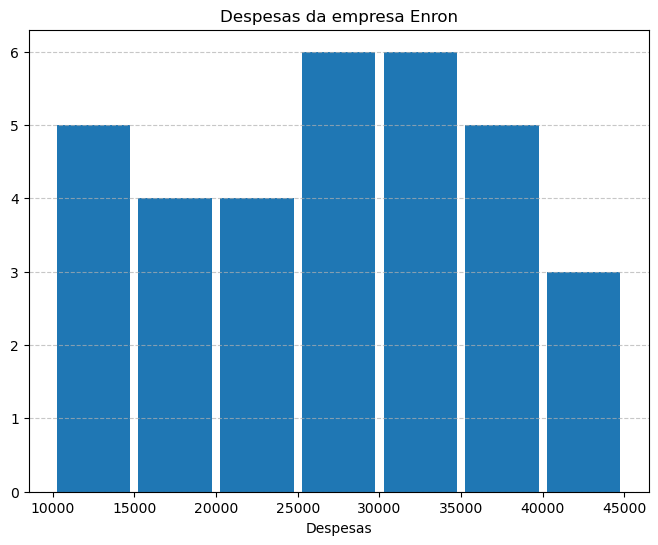

In [31]:
plt.figure(figsize = (8,6))

salario = df_novo['despesas']

plt.figure(figsize = (8,6))
plt.hist(salario, bins=range(10000, 50000, 5000), rwidth=0.9)
plt.title('Despesas da empresa Enron')
plt.xlabel('Despesas')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

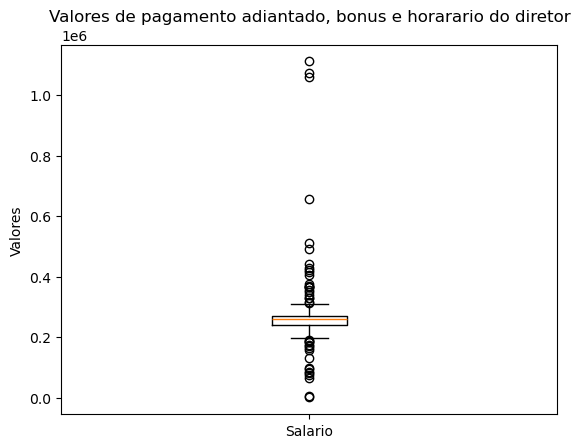

In [32]:
plt.boxplot(df_novo['salario'], labels=['Salario'])

plt.title('Valores de pagamento adiantado, bonus e horarario do diretor')
plt.ylabel('Valores')

plt.show()

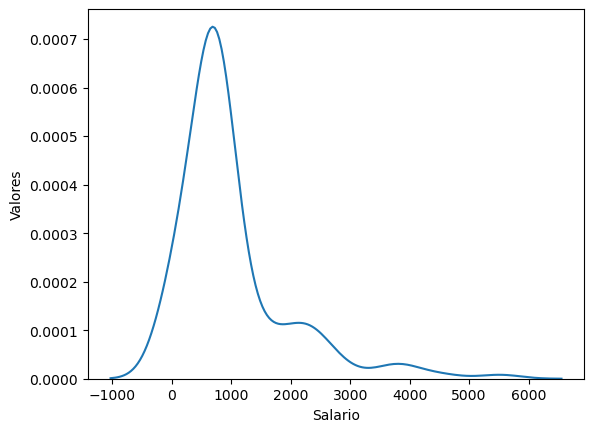

In [33]:
sns.kdeplot(df_novo['recibo_compart_pessoa_interesse'])

plt.xlabel('Salario')
plt.ylabel('Valores')
plt.show()

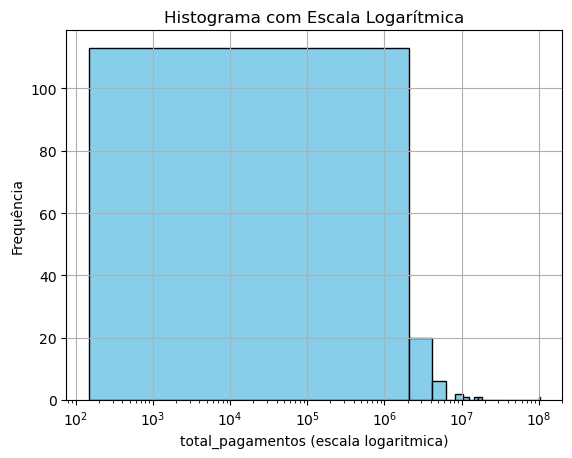

In [34]:
plt.hist(df_novo['total_pagamentos'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.xscale('log')  # Escala logarítmica no eixo X
plt.title('Histograma com Escala Logarítmica')
plt.xlabel('total_pagamentos (escala logaritmica)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

____________________________________________________________________________________________________________________________________

# Análise multivariada de dados

Nesta seção, você deverá conduzir uma análise de dados multivariada. O objetivo desta etapa é encontrar relações e/ou correlações entre as variáveis da base de dados da Enron.
Apesar de mais flexível que a etapa anterior, esta é uma das etapas mais importantes da ATP, uma vez que esta base de dados possui inúmeros relacionamentos interessantes a serem descobertos e reportados.
Nesta etapa, você deverá criar visualizações, contudo, sempre no seguinte formato:
- Apresentar uma pergunta/hipótese sobre os dados,
- Criar uma visualização que responda esta pergunta ou confirme a hipótese, e
- Análise dos dados a partir desta visualização, respondendo textualmente a pergunta/hipótese afirmada anteriormente, assim como apresentando ao leitor os principais insights obtidos a partir da visualização.

Esta etapa do projeto requer que ao menos 20 visualizações bivariadas sejam criadas. Sinta-se a vontade para utilizar gráficos de barra, box-plots, violin plots, ou demais gráficos discutidos durante o curso. Note, contudo, que a utilização dos gráficos deverá ser apropriada, isto é, o tipo de cada gráfico deve ser aderente com os tipos de dados sendo apresentados.

1) Qual a quantidade de mensagens enviadas de cada email?

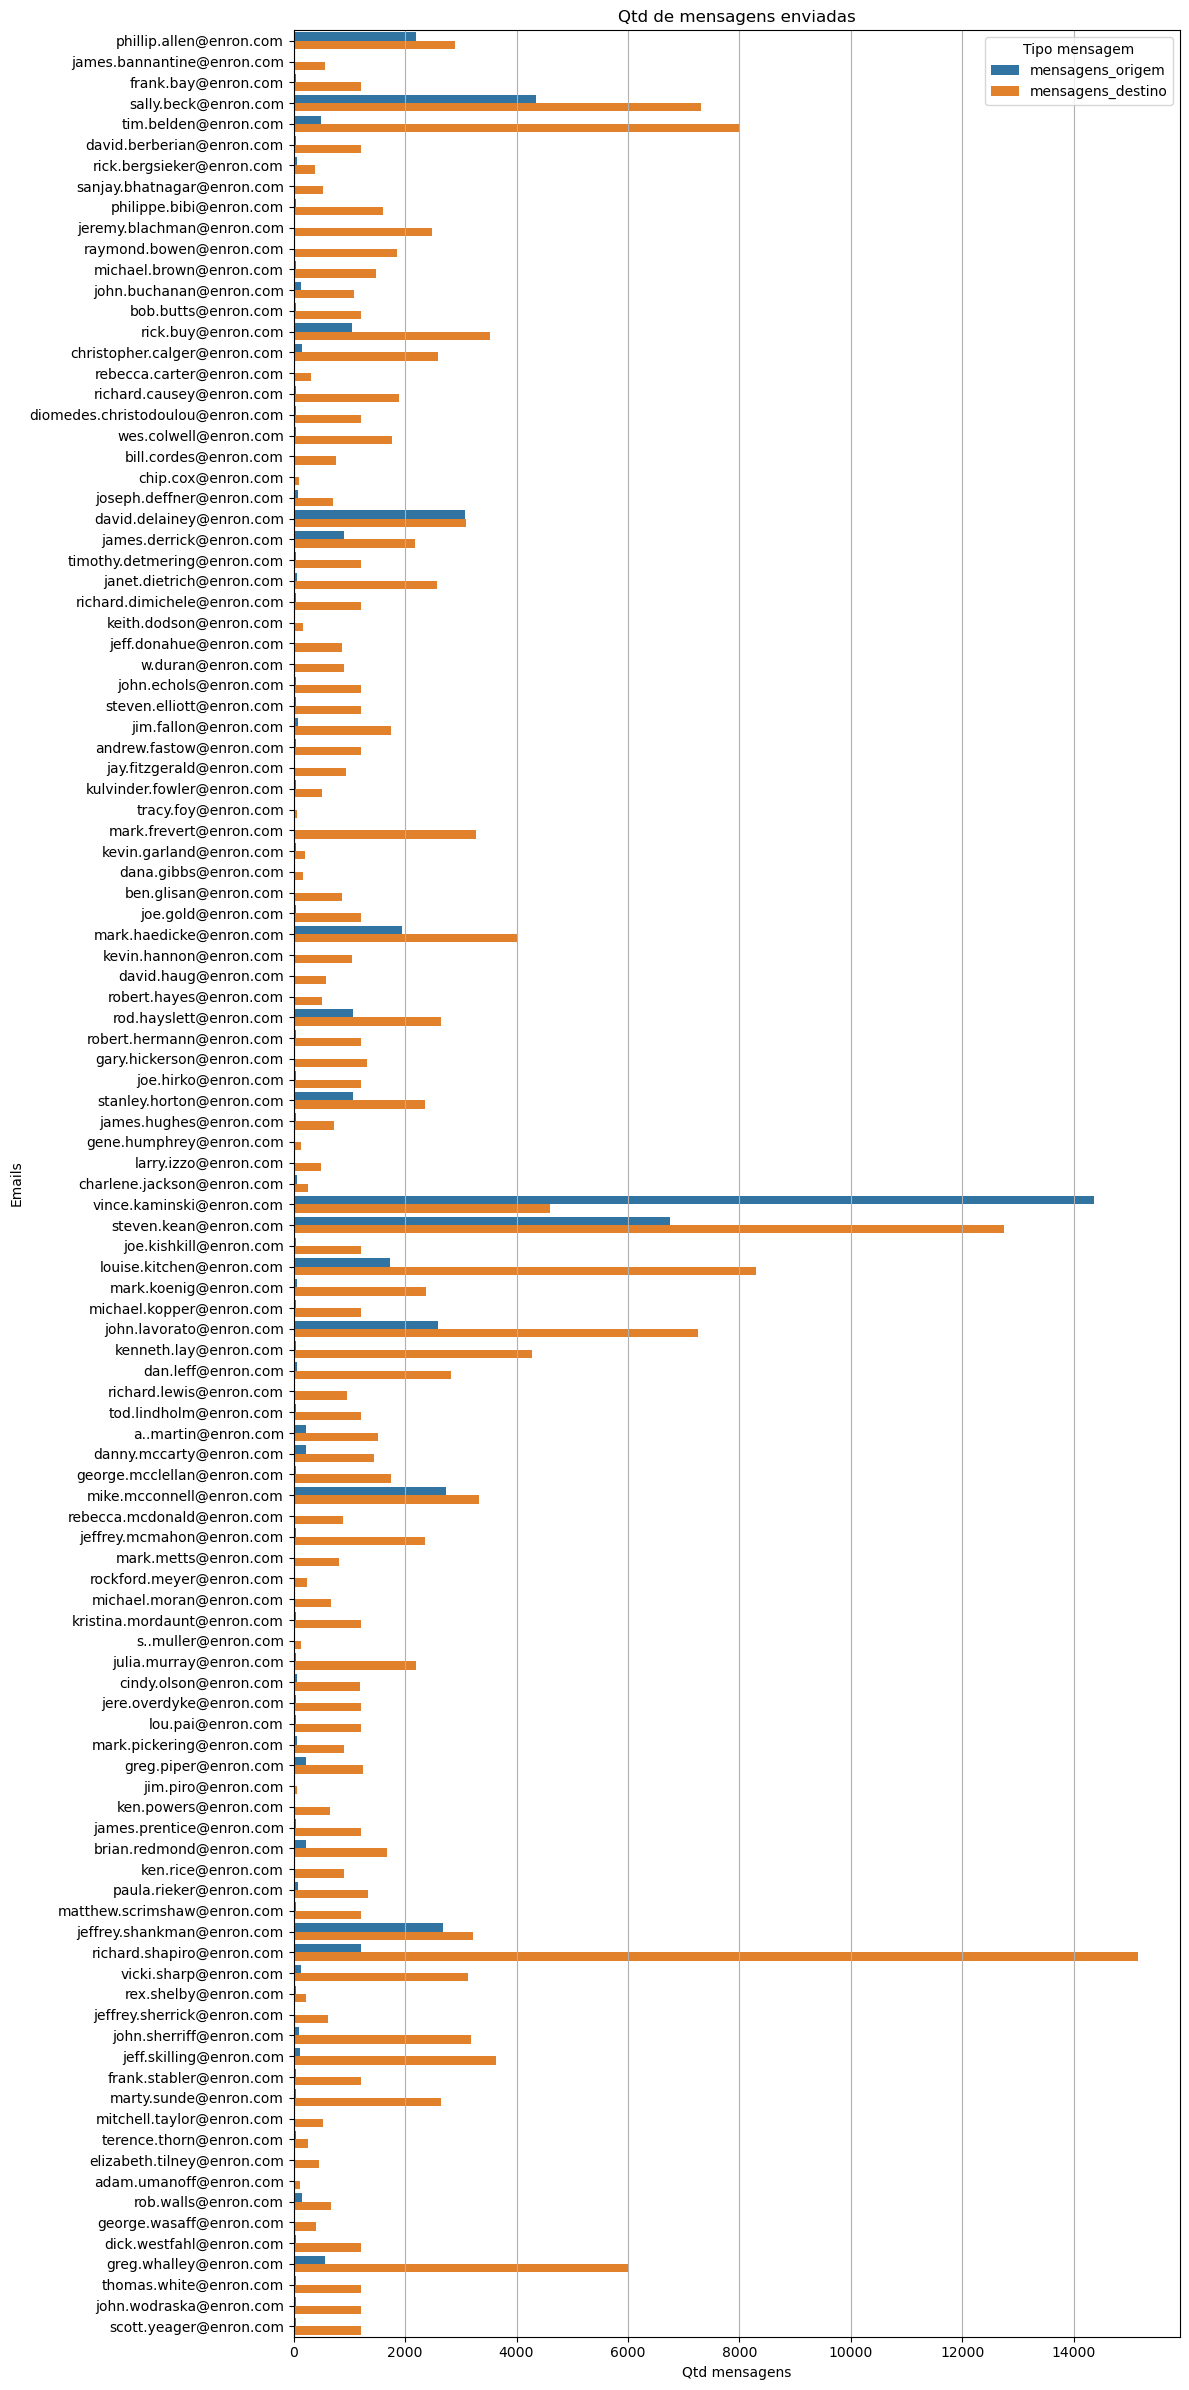

In [35]:
df_long = df_novo.melt(id_vars='email', value_vars=['mensagens_origem', 'mensagens_destino'],
                  var_name='Tipo mensagem', value_name='Qtd mensagens')

plt.figure(figsize=(12,24))
sns.barplot(data=df_long, y='email', x='Qtd mensagens', hue='Tipo mensagem')

plt.title("Qtd de mensagens enviadas")
plt.xlabel("Qtd mensagens")
plt.ylabel("Emails")
plt.grid(True, axis='x')
plt.legend(title="Tipo mensagem")
plt.tight_layout()
plt.show()

É possível verificar que houve muitos emails enviados além de recebidos

____________________________________________________________________________________________________________________________________

2) Qual a relação entre os pagamentos adiados e o salário pago?

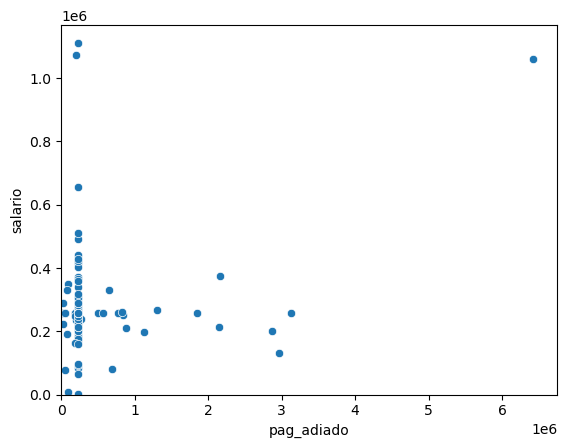

In [36]:
sns.scatterplot(x = 'pag_adiado', y = 'salario', data = df_novo)
plt.ylim(0, None)
plt.xlim(0, None)
plt.show()

____________________________________________________________________________________________________________________________________

3. Relação entre os mensagens de pessoa de interesse para outras pessoas

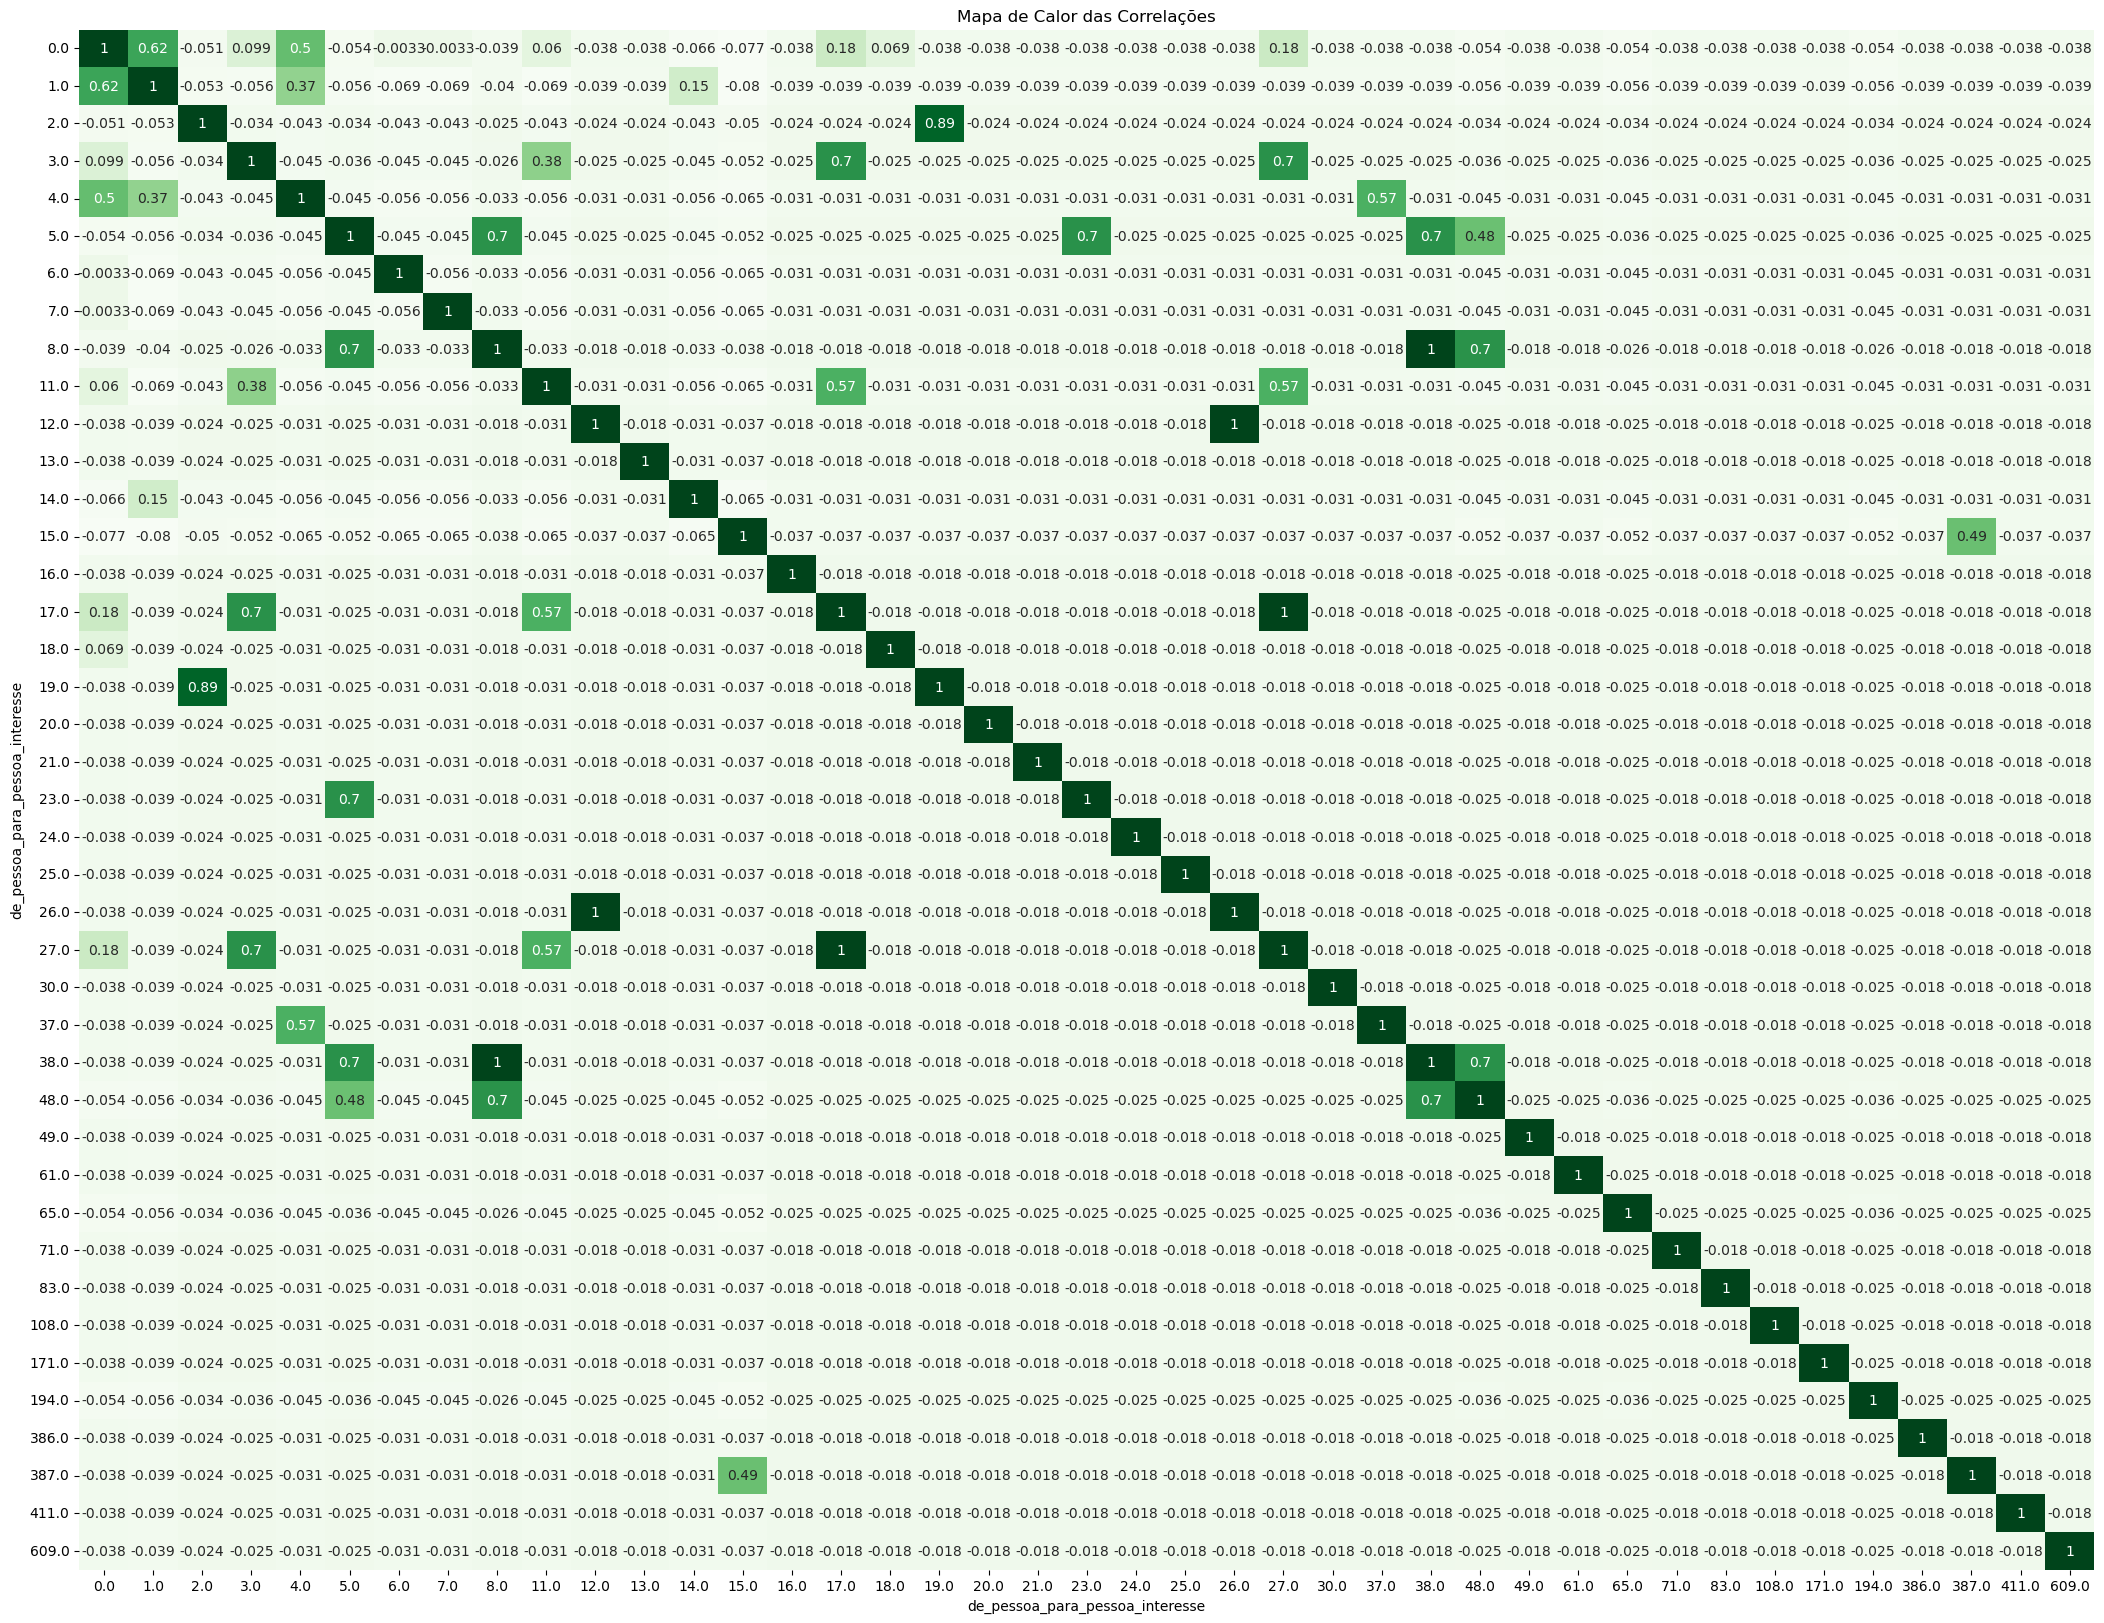

In [37]:
plt.figure(figsize=(26,20))
sns.heatmap(pd.crosstab(df_novo.pessoa_interesse_para_pessoa, df_novo.de_pessoa_para_pessoa_interesse).corr(),
            cmap = "Greens", annot=True, cbar=False)

plt.title('Mapa de Calor das Correlações')
plt.show()

____________________________________________________________________________________________________________________________________

4) Qual o total de pagamento e o salario dos funcionários?

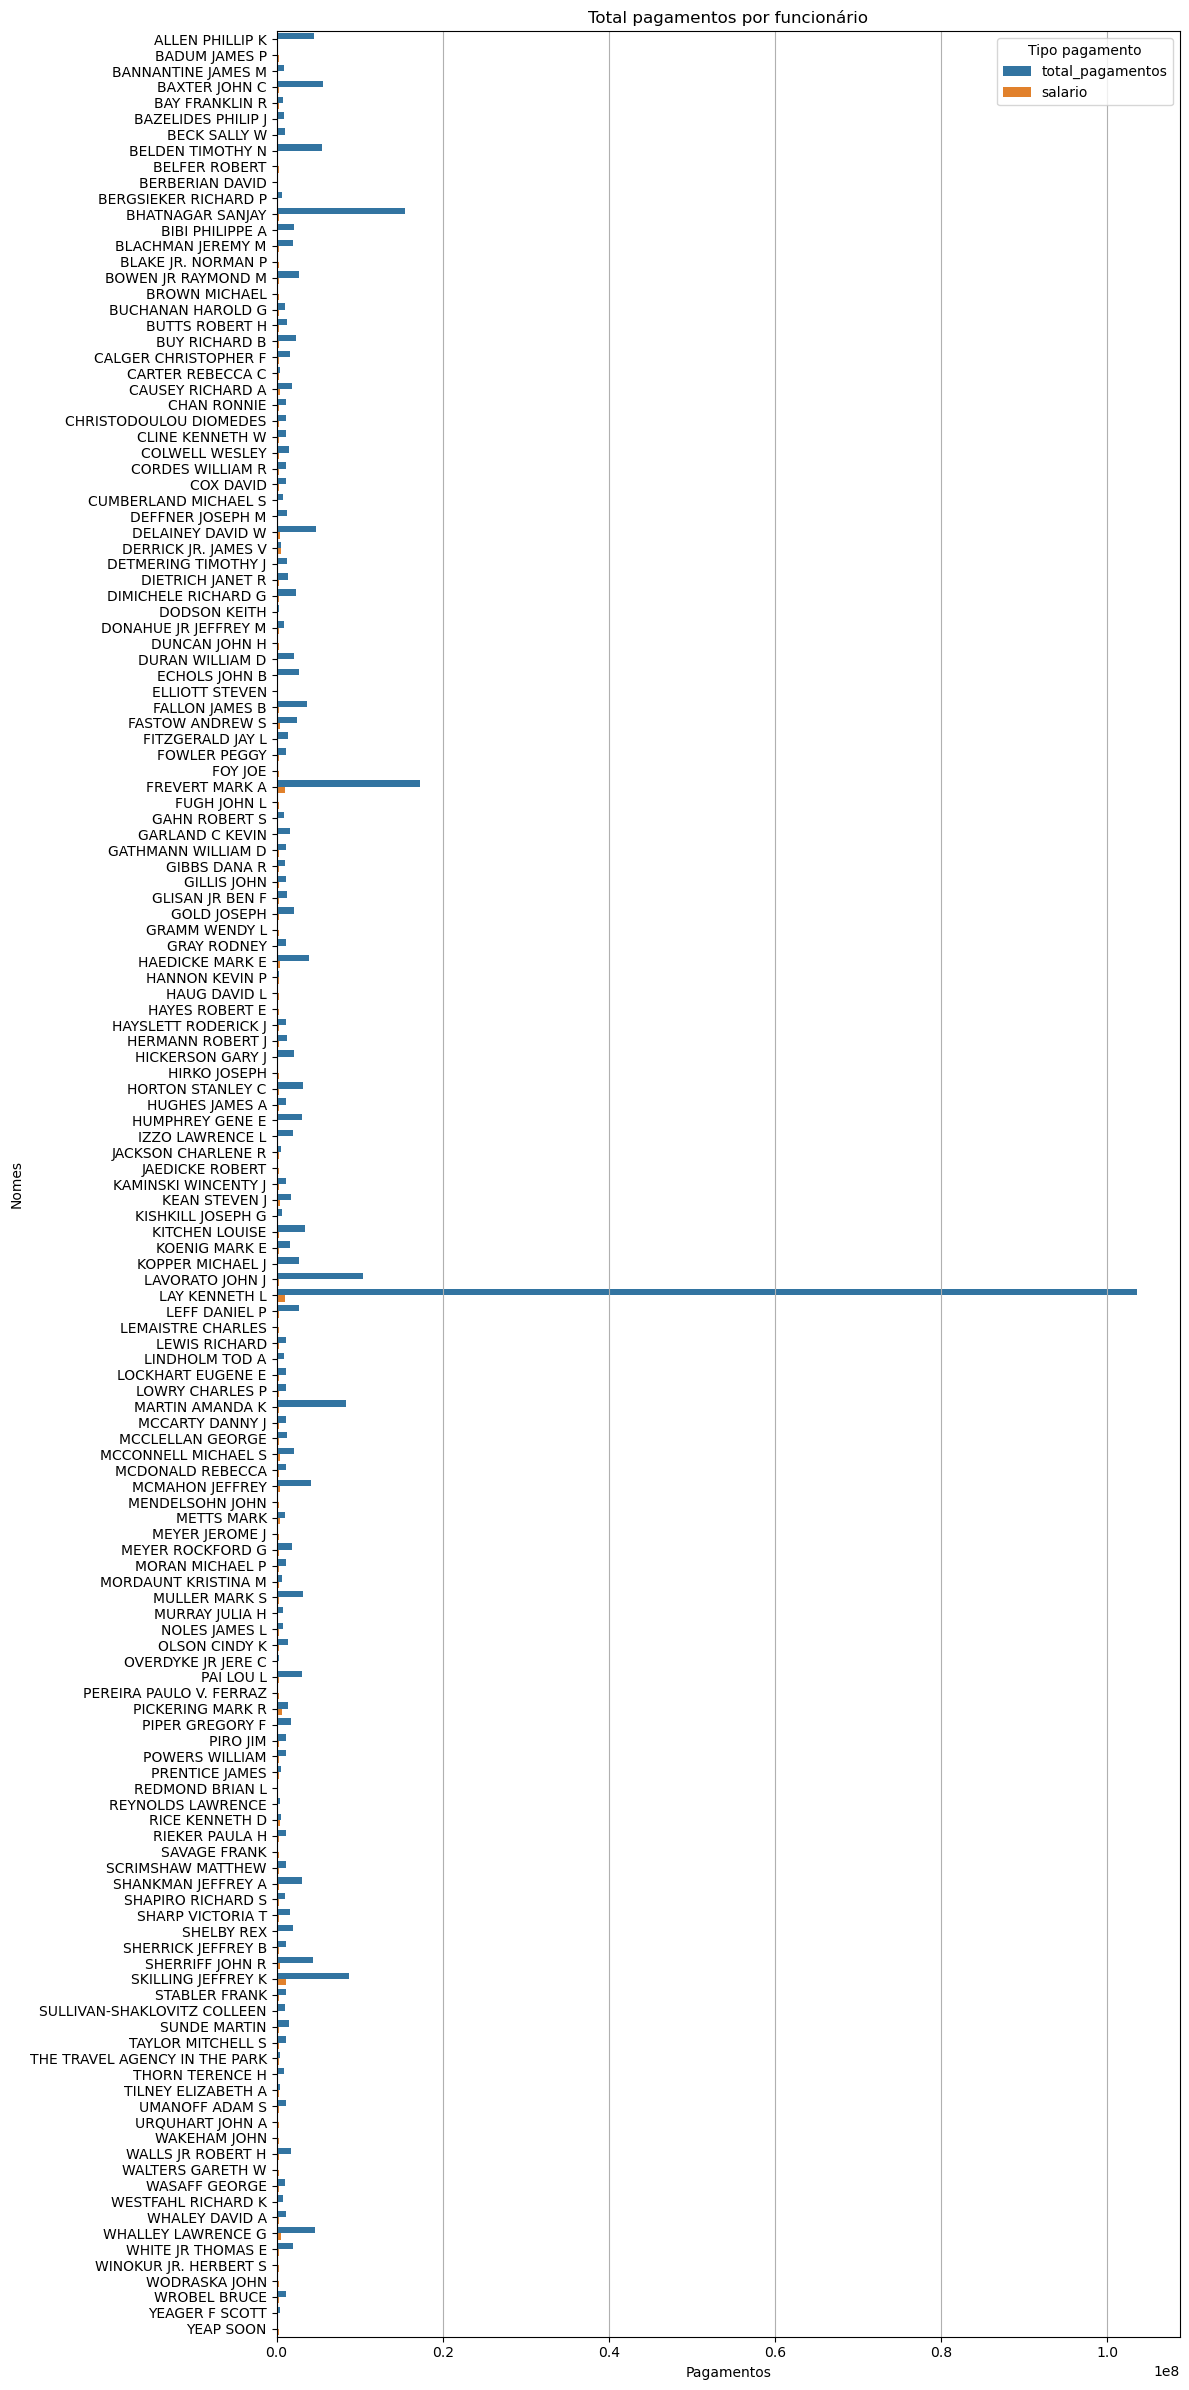

In [38]:
df_long = df_novo.melt(id_vars='nome', value_vars=['total_pagamentos', 'salario',],
                  var_name='Tipo pagamento', value_name='Pagamentos')

plt.figure(figsize=(12,24))
sns.barplot(data=df_long, y='nome', x='Pagamentos', hue='Tipo pagamento')

plt.title("Total pagamentos por funcionário")
plt.xlabel("Pagamentos")
plt.ylabel("Nomes")
plt.grid(True, axis='x')
plt.legend(title="Tipo pagamento")
plt.tight_layout()
plt.show()

____________________________________________________________________________________________________________________________________

5) Qual a relação entre a renda adiada, pagamento adiado e o bônus?

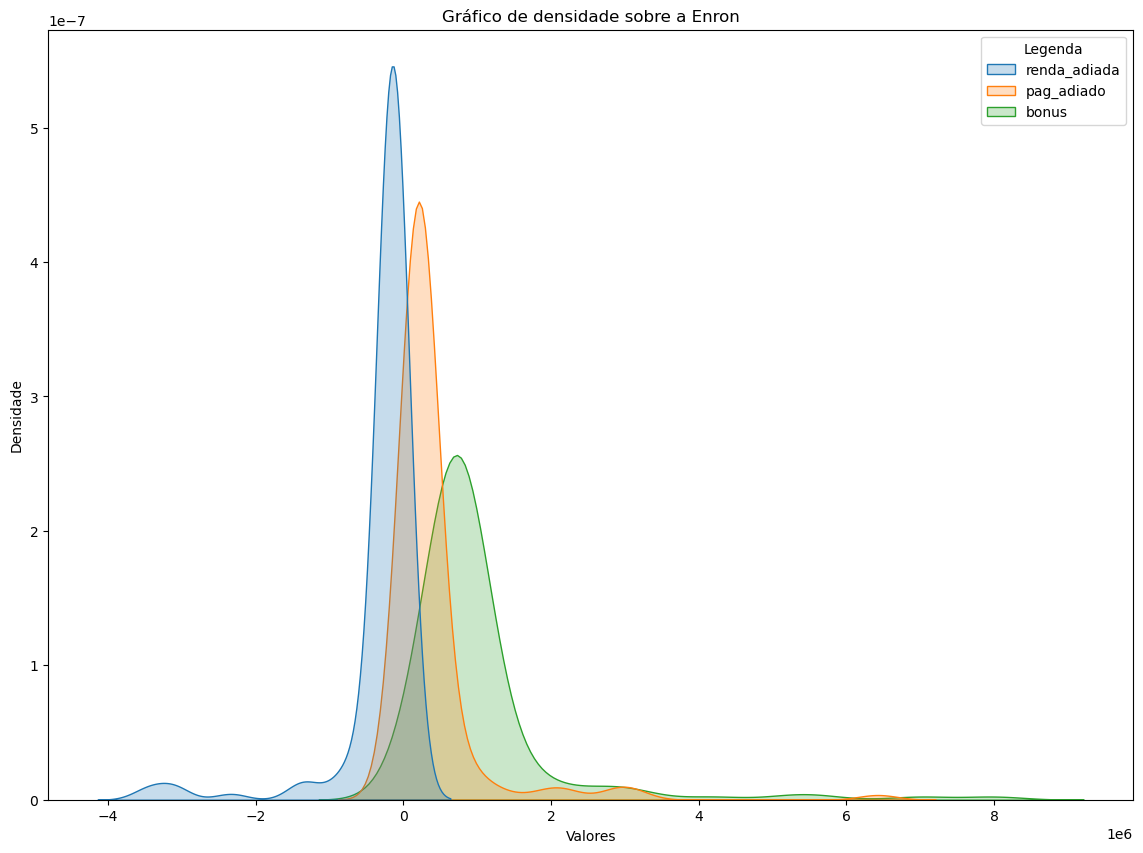

In [86]:
df_meltado = df_novo.melt(value_vars=['renda_adiada', 'pag_adiado', 'bonus'],
                          var_name='Legenda', value_name='valor')

#df_long = df_novo.melt(id_vars='nome', value_vars=['total_pagamentos', 'salario'],
#                 var_name='Tipo pagamento', value_name='Pagamentos')
plt.figure(figsize=(14, 10))
sns.kdeplot(df_meltado.dropna(),  # remove NaN antes do plot
    x='valor',
    fill=True,
    thresh=0.05,                        # ignora áreas com densidade muito baixa
    hue='Legenda'
)
plt.title('Gráfico de densidade sobre a Enron')
plt.xlabel('Valores')
plt.ylabel('Densidade')
plt.show()

____________________________________________________________________________________________________________________________________

6) Qual o valor dos recibos das pessoas de interesse (POI)?

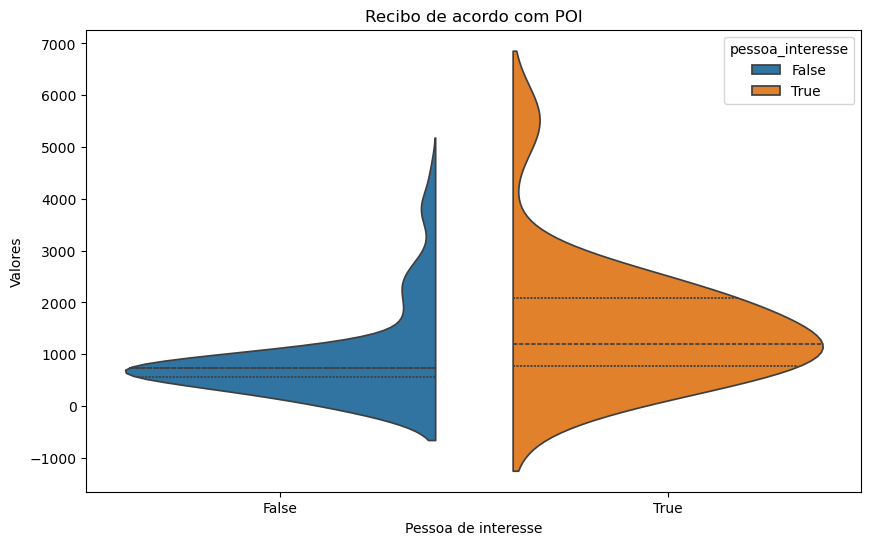

In [41]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df_novo, x="pessoa_interesse", y="recibo_compart_pessoa_interesse", hue="pessoa_interesse", split=True, inner="quart")

plt.title("Recibo de acordo com POI")
plt.xlabel("Pessoa de interesse")
plt.ylabel("Valores")
plt.show()

____________________________________________________________________________________________________________________________________

7) Relação das mensagens de origem das pessoas de interesse (POI)

<Figure size 2400x2000 with 0 Axes>

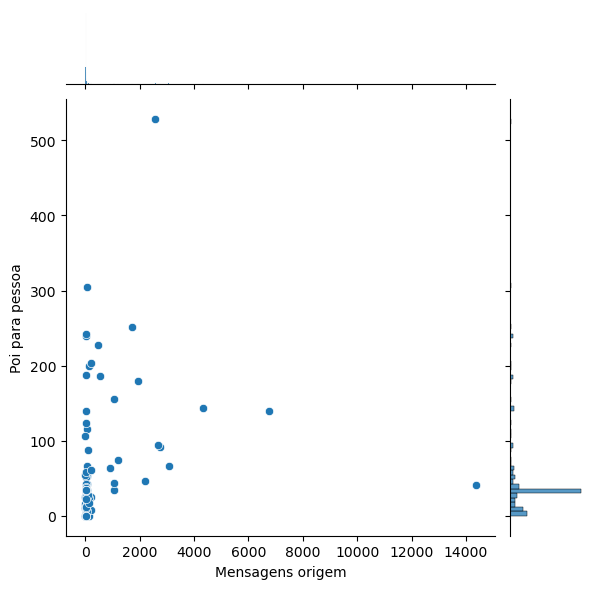

In [42]:
plt.figure(figsize = (24,20))
sns.jointplot(x = 'mensagens_origem', y = 'pessoa_interesse_para_pessoa', data = df_novo)

plt.xlabel('Mensagens origem')
plt.ylabel('Poi para pessoa')
plt.show()

____________________________________________________________________________________________________________________________________

8) Relação das mensagens entre as pessoas sem interesse e pessoas de interesse

<Figure size 2400x2000 with 0 Axes>

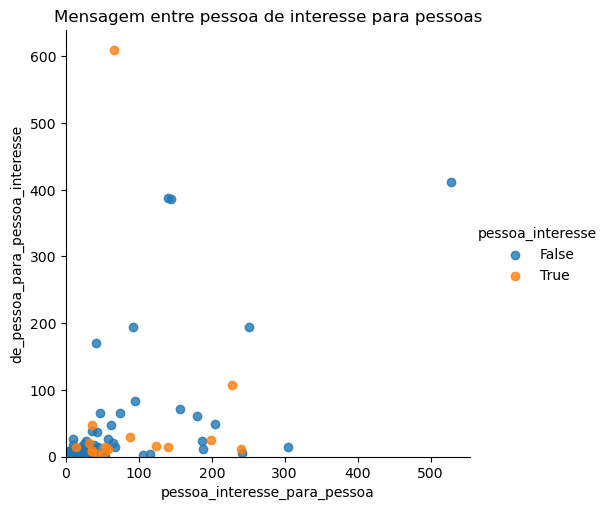

In [43]:
plt.figure(figsize = (24,20))
sns.lmplot(x = 'pessoa_interesse_para_pessoa', y = 'de_pessoa_para_pessoa_interesse', data = df_novo,
          fit_reg = False,
          hue = 'pessoa_interesse')

plt.title("Mensagem entre pessoa de interesse para pessoas")
plt.ylim(0, None)
plt.xlim(0, None)
plt.show()

____________________________________________________________________________________________________________________________________

9) Relação das mensagens de origem de pessoas sem interesse (não POI)

<Figure size 2400x2000 with 0 Axes>

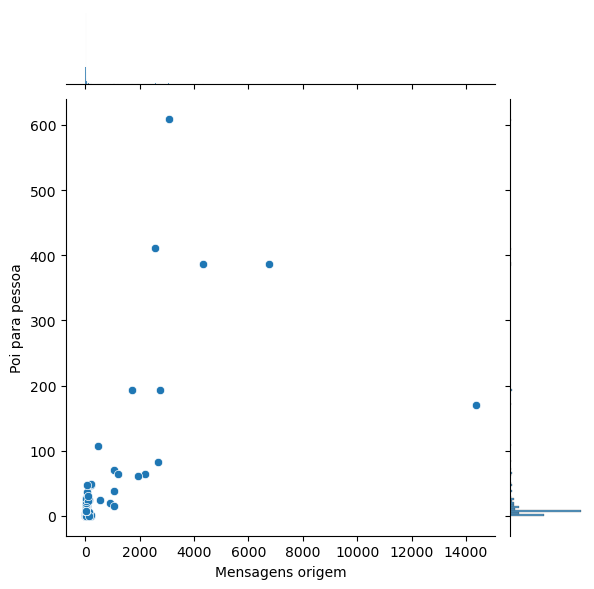

In [44]:
plt.figure(figsize = (24,20))
sns.jointplot(x = 'mensagens_origem', y = 'de_pessoa_para_pessoa_interesse', data = df_novo)

plt.xlabel('Mensagens origem')
plt.ylabel('Poi para pessoa')
plt.show()

____________________________________________________________________________________________________________________________________

10) Qual o salário dos funcionários da Enron, separados entre POI e não POI?

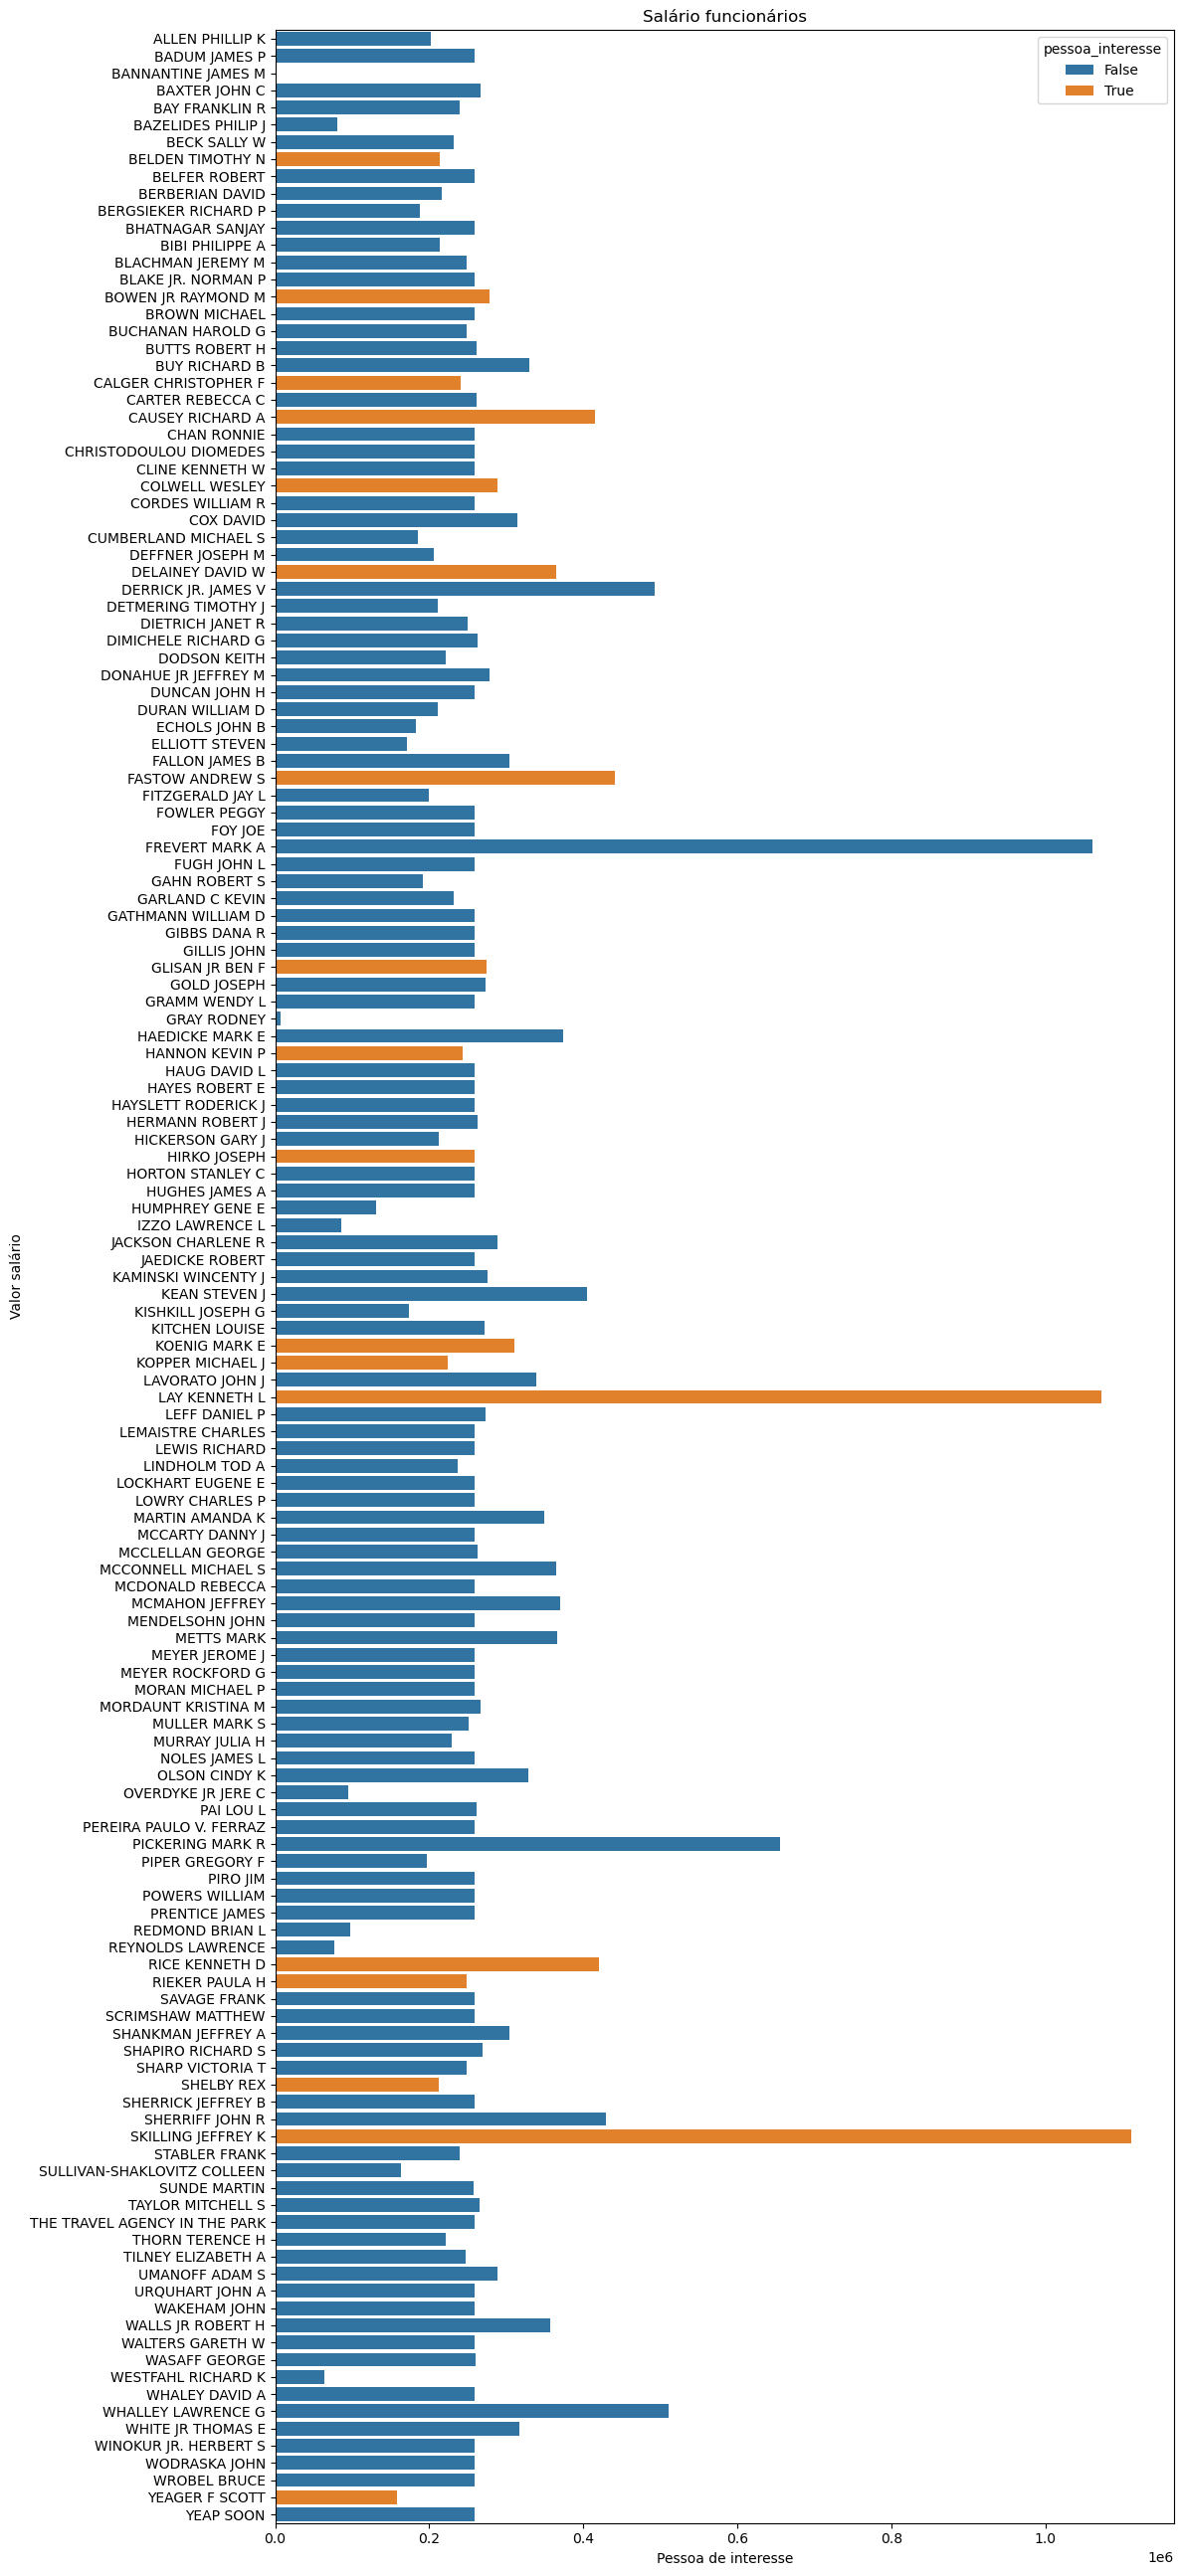

In [45]:
plt.figure(figsize = (12,26))
sns.barplot(x='salario', y='nome', hue = 'pessoa_interesse', data=df_novo)

plt.title('Salário funcionários')
plt.xlabel('Pessoa de interesse')
plt.ylabel('Valor salário')
plt.tight_layout()
plt.show()

____________________________________________________________________________________________________________________________________

11) Relação entre valor total do estoque e o estoque restrito

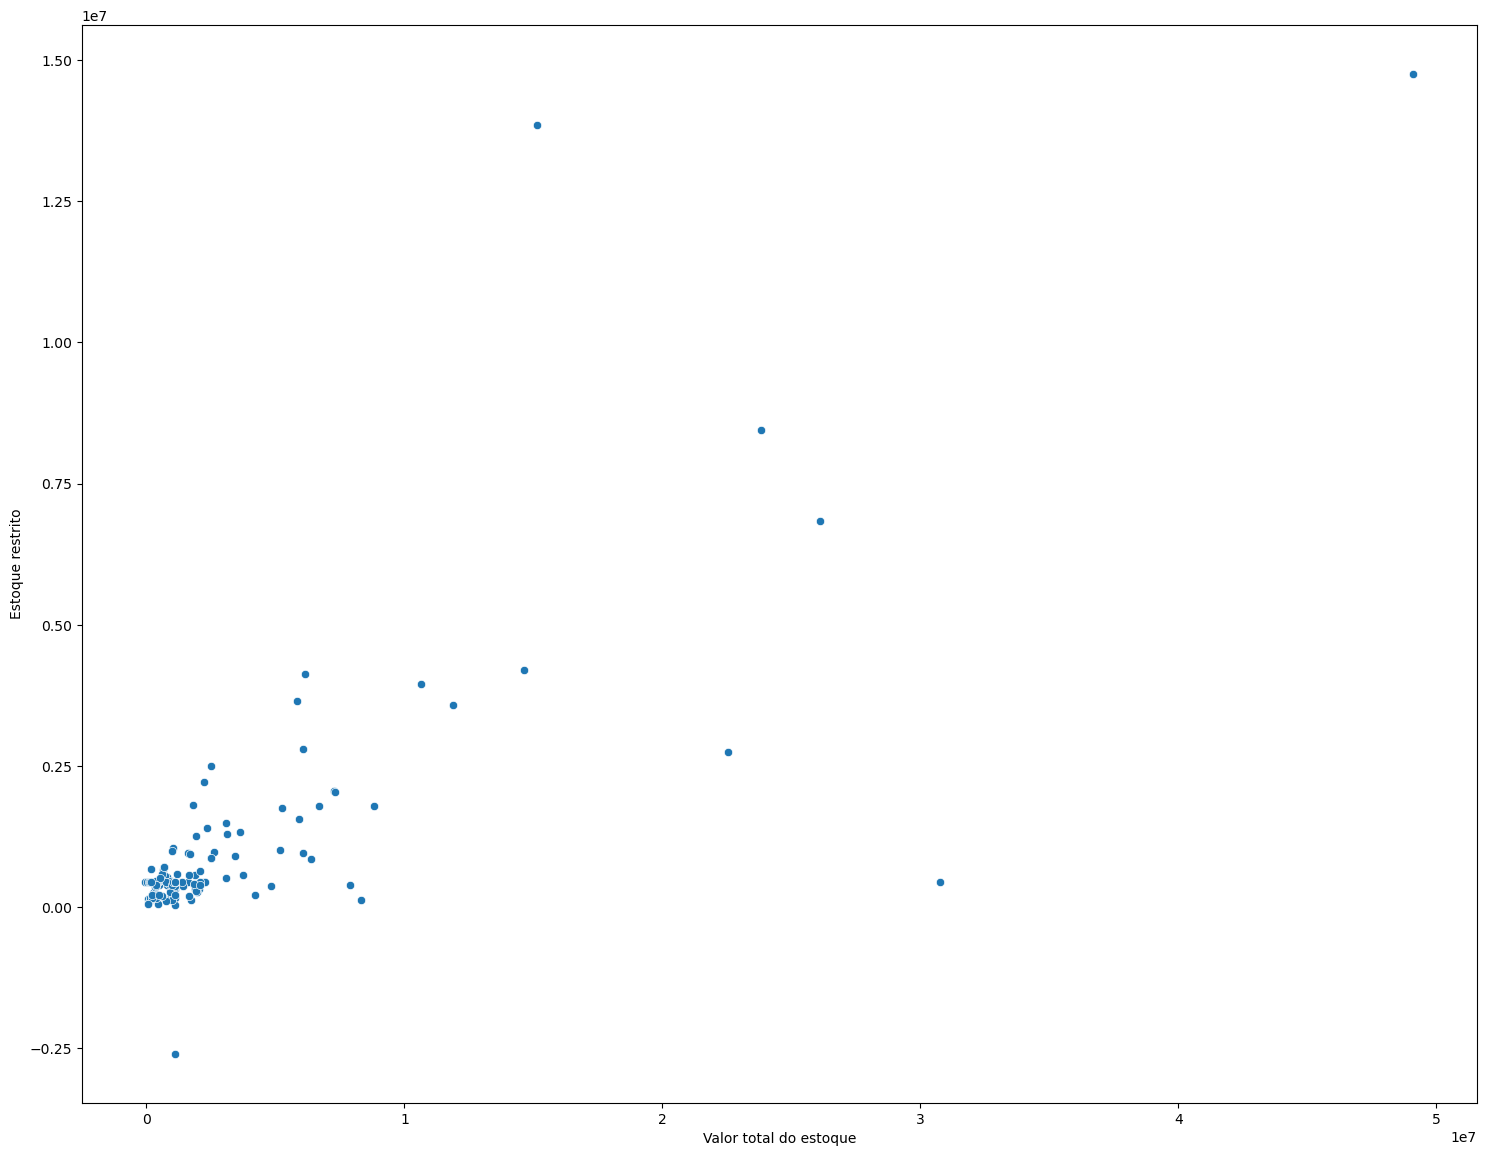

In [46]:
plt.figure(figsize = (18,14))
sns.scatterplot(x = 'valor_total_estoque', y = 'estoque_restrito', data = df_novo)

plt.xlabel('Valor total do estoque')
plt.ylabel('Estoque restrito')
plt.show()

____________________________________________________________________________________________________________________________________

12) Há números acima da média entre despesas, total de pagamentos e o incentivo a longo prazo?

C:\Users\User\AppData\Local\Temp\ipykernel_12852\2767681540.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_filtrado = df_novo[colunas].applymap(lambda x: x if x > 10000 else None)


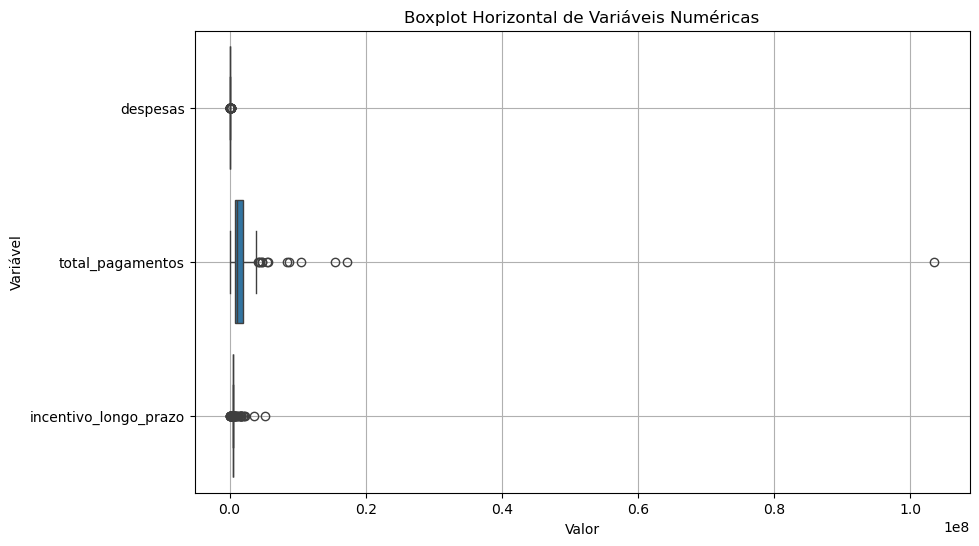

In [47]:
colunas = ['despesas', 'total_pagamentos', 'incentivo_longo_prazo']

# Filtrar apenas os valores > 10000 por coluna e montar um DataFrame "long"
df_filtrado = df_novo[colunas].applymap(lambda x: x if x > 10000 else None)
df_meltado = df_filtrado.melt(var_name='Variável', value_name='Valor').dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_meltado, y = 'Variável', x = 'Valor', orient='h')
plt.title('Boxplot Horizontal de Variáveis Numéricas')
plt.xlabel('Valor')
plt.grid(True)
plt.show()

____________________________________________________________________________________________________________________________________

13) Relação das mensagens entre POI e não POI?

<Figure size 2000x1600 with 0 Axes>

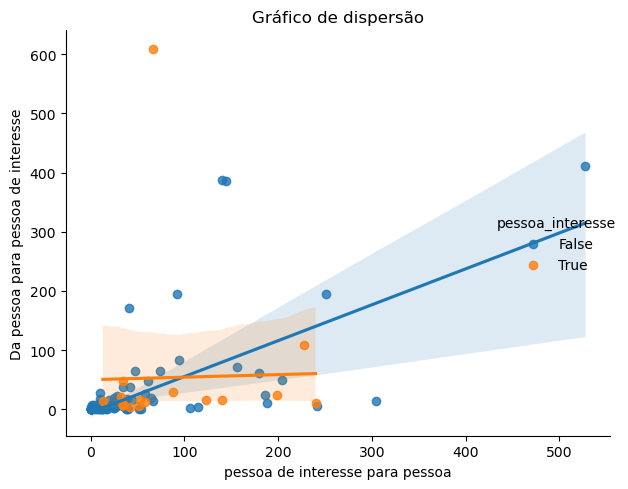

In [48]:
plt.figure(figsize=(20,16))
sns.lmplot(data=df_novo, x="pessoa_interesse_para_pessoa", y="de_pessoa_para_pessoa_interesse", hue="pessoa_interesse")

plt.title('Gráfico de dispersão')
plt.xlabel('pessoa de interesse para pessoa')
plt.ylabel('Da pessoa para pessoa de interesse')
plt.tight_layout()
plt.show()

____________________________________________________________________________________________________________________________________

14) Relação de salário, pagamento adiado e despesas das pessoas de interesse e não-interesse?

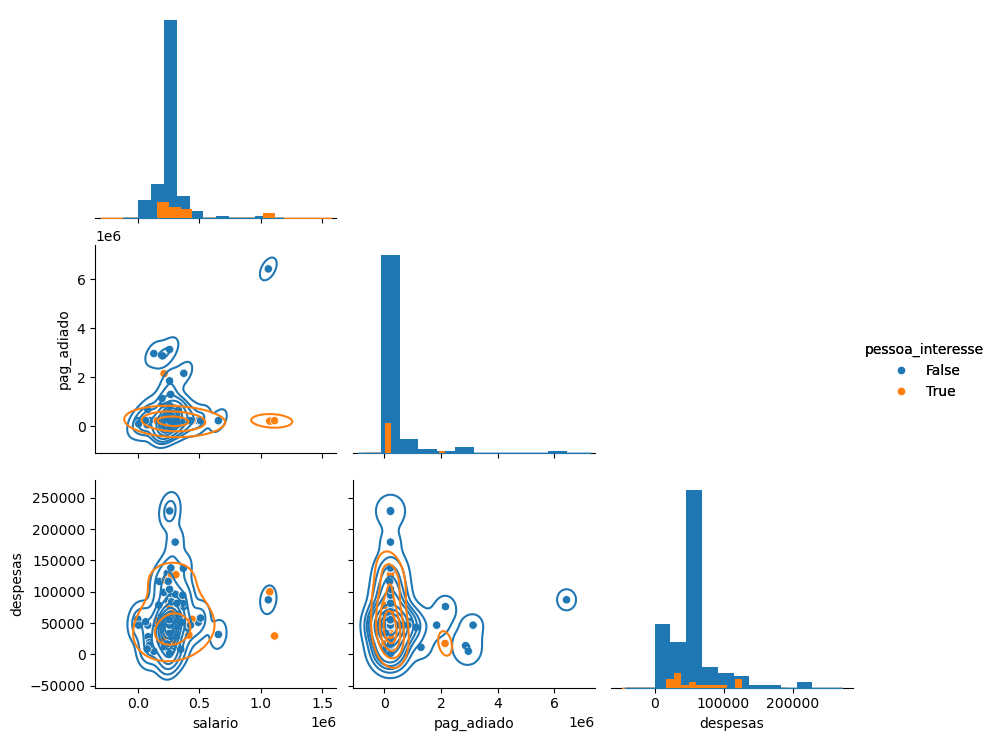

In [49]:
grid = sns.pairplot(data=df_novo, vars=["salario", "pag_adiado", "despesas"], hue="pessoa_interesse", corner=True)

grid = grid.map_upper(plt.scatter)
grid = grid.map_diag(plt.hist)
grid = grid.map_lower(sns.kdeplot).add_legend()

____________________________________________________________________________________________________________________________________

15) Qual as opções exercidas e outros entre pessoas de interesse e não-interesse? 

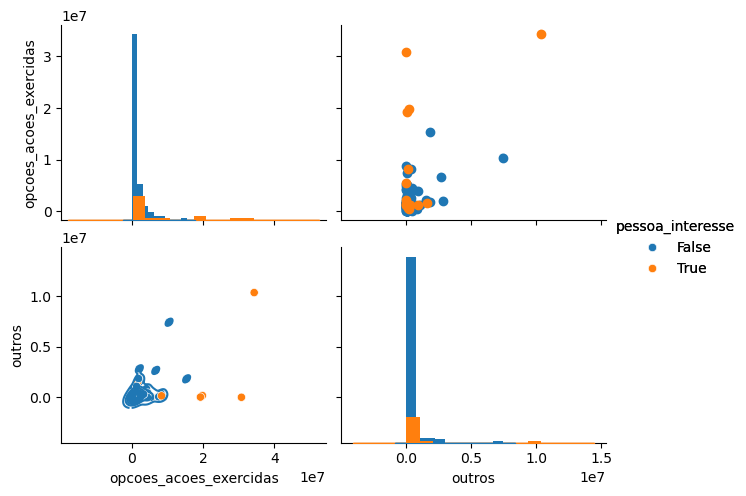

In [50]:
grid = sns.pairplot(data=df_novo, vars=["opcoes_acoes_exercidas", "outros"], hue="pessoa_interesse", corner=False)

grid = grid.map_upper(plt.scatter)
grid = grid.map_diag(plt.hist)
grid = grid.map_lower(sns.kdeplot).add_legend()

____________________________________________________________________________________________________________________________________

16) Quais as despesas entre as pessoas de interesse e não-interesse?

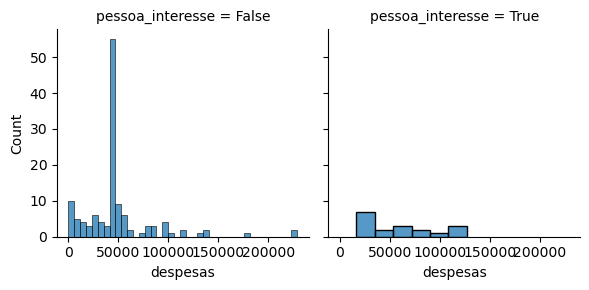

In [51]:
facet = sns.FacetGrid(df_novo, col="pessoa_interesse")
facet.map(sns.histplot, "despesas")

____________________________________________________________________________________________________________________________________

17) Qual a relação entre pessoas de interesse e outros?

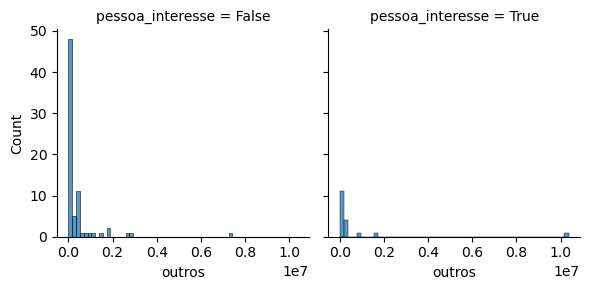

In [38]:
facet = sns.FacetGrid(df_novo, col="pessoa_interesse")
facet.map(sns.histplot, "outros")

____________________________________________________________________________________________________________________________________

18) Relação entre o valor do estoque total e o número de estoque restrito, conforme as pessoas de interesse e sem interesse?

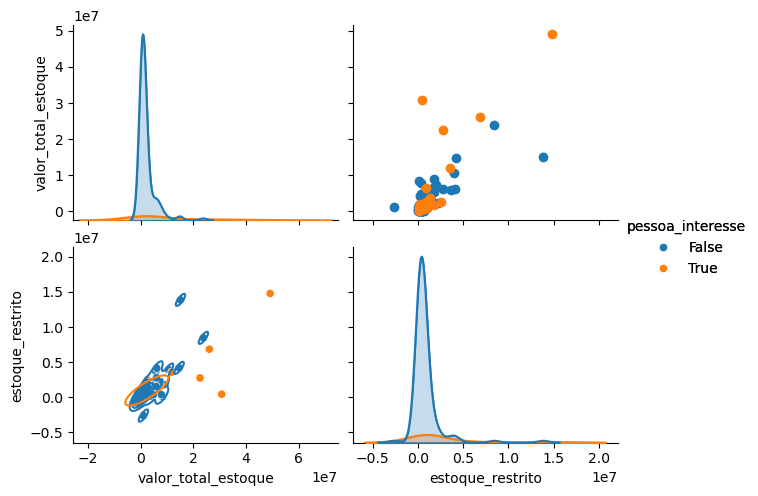

In [53]:
grid = sns.pairplot(data=df_novo, vars=["valor_total_estoque", "estoque_restrito"], hue="pessoa_interesse")

grid = grid.map_upper(plt.scatter)
grid = grid.map_diag(sns.kdeplot)
grid = grid.map_lower(sns.kdeplot).add_legend()

____________________________________________________________________________________________________________________________________

19) Qual os valores dos bônus entre as pessoas de interesse e pessoas sem interesse?

C:\Users\User\anaconda3\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


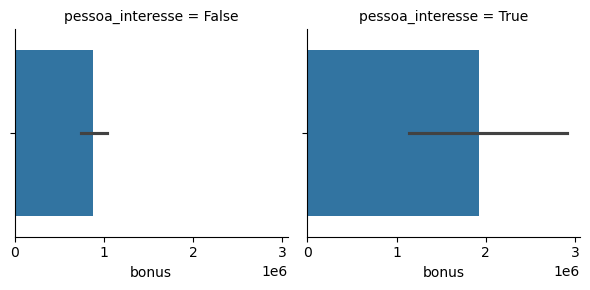

In [54]:
facet = sns.FacetGrid(df_novo, col="pessoa_interesse")
facet.map(sns.barplot, "bonus")

____________________________________________________________________________________________________________________________________

20) Qual a relação entre as mensagens de origem entre pessoas de interesse e pessoas sem interesse?

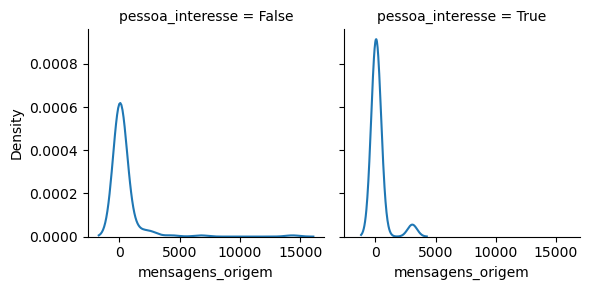

In [89]:
facet = sns.FacetGrid(df_novo, col="pessoa_interesse")
facet.map(sns.kdeplot, "mensagens_origem")

____________________________________________________________________________________________________________________________________

# Visualizações efetivas

Nesta seção, você deve **escolher** e **melhorar** 5 visualizações criadas anteriormente.
A chave aqui é melhorar estas visualizações com o objetivo de apresentá-las a uma audiência que não conheça a base de dados da Enron e/ou não trabalhe com análise de dados.
**Sendo assim, garanta que o tamanho, cores, texturas e outras componentes visuais sejam bem escolhidas e utilizadas, sempre visando garantir que a informação seja passada de forma clara e correta para a audiência.**

Para cada um destas visualizações, garanta que as seguintes etapas foram seguidas:

1. Criação de visualização: Criar novamente a visualização, garantindo que ela possui título e rótulos nos eixos e legenda (caso necessário)
2. Cores: Garantir que o uso de cores é correto, de acordo com o objetivo da visualização e também com escalas de cores visando leitores daltônicos
3. Cores e tamanhos: Garantir que texturas e tamanhos são utilizados de forma correta
4. Chart junk: Garantir que a visualização possui um baixo fator de "chart junk"
5. Avaliação por pares: você deverá angariar feedback de três pessoas sobre sua visualização. Você deverá apresentar o feedback de cada pessoa, assim como deve discutir, de forma textual, se este feedback acarretou em alguma mudança de design. Você deve apresentar evidências das mudanças realizadas, isto é, a visualização **antes** e **depois** do *feedback*.
6. Descrição: cada visualização deve ser acompanhada de uma descrição que inclua as principais descobertas (*insights*) que podem ser extraídos a partir dela.




____________________________________________________________________________________________________________________________________

6) Qual o valor dos recibos das pessoas de interesse (POI)?

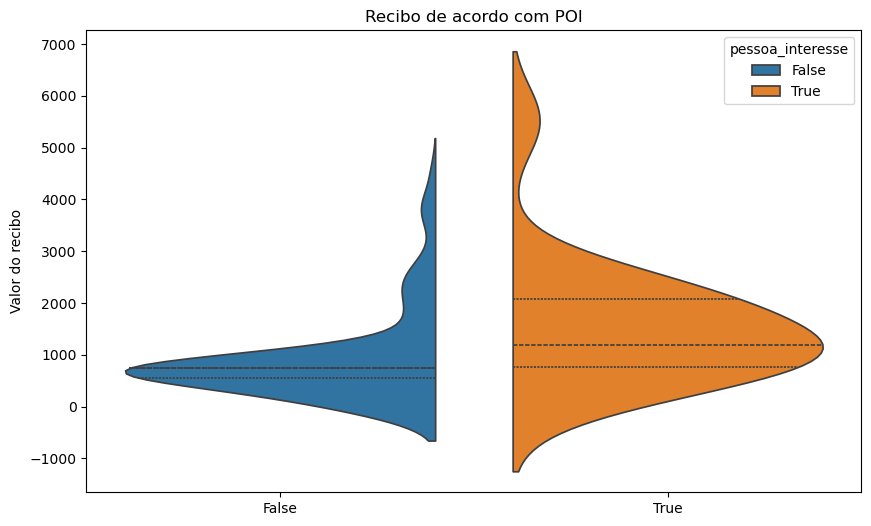

In [59]:
# Remoção do titulo do eixo X

plt.figure(figsize=(10,6))
sns.violinplot(data=df_novo, x="pessoa_interesse", y="recibo_compart_pessoa_interesse", hue="pessoa_interesse", split=True, inner="quart")

plt.title("Recibo de acordo com POI")
plt.ylabel("Valor do recibo")
plt.xlabel('')
plt.show()

____________________________________________________________________________________________________________________________________

8) Relação das mensagens entre as pessoas sem interesse e pessoas de interesse

<Figure size 2400x2000 with 0 Axes>

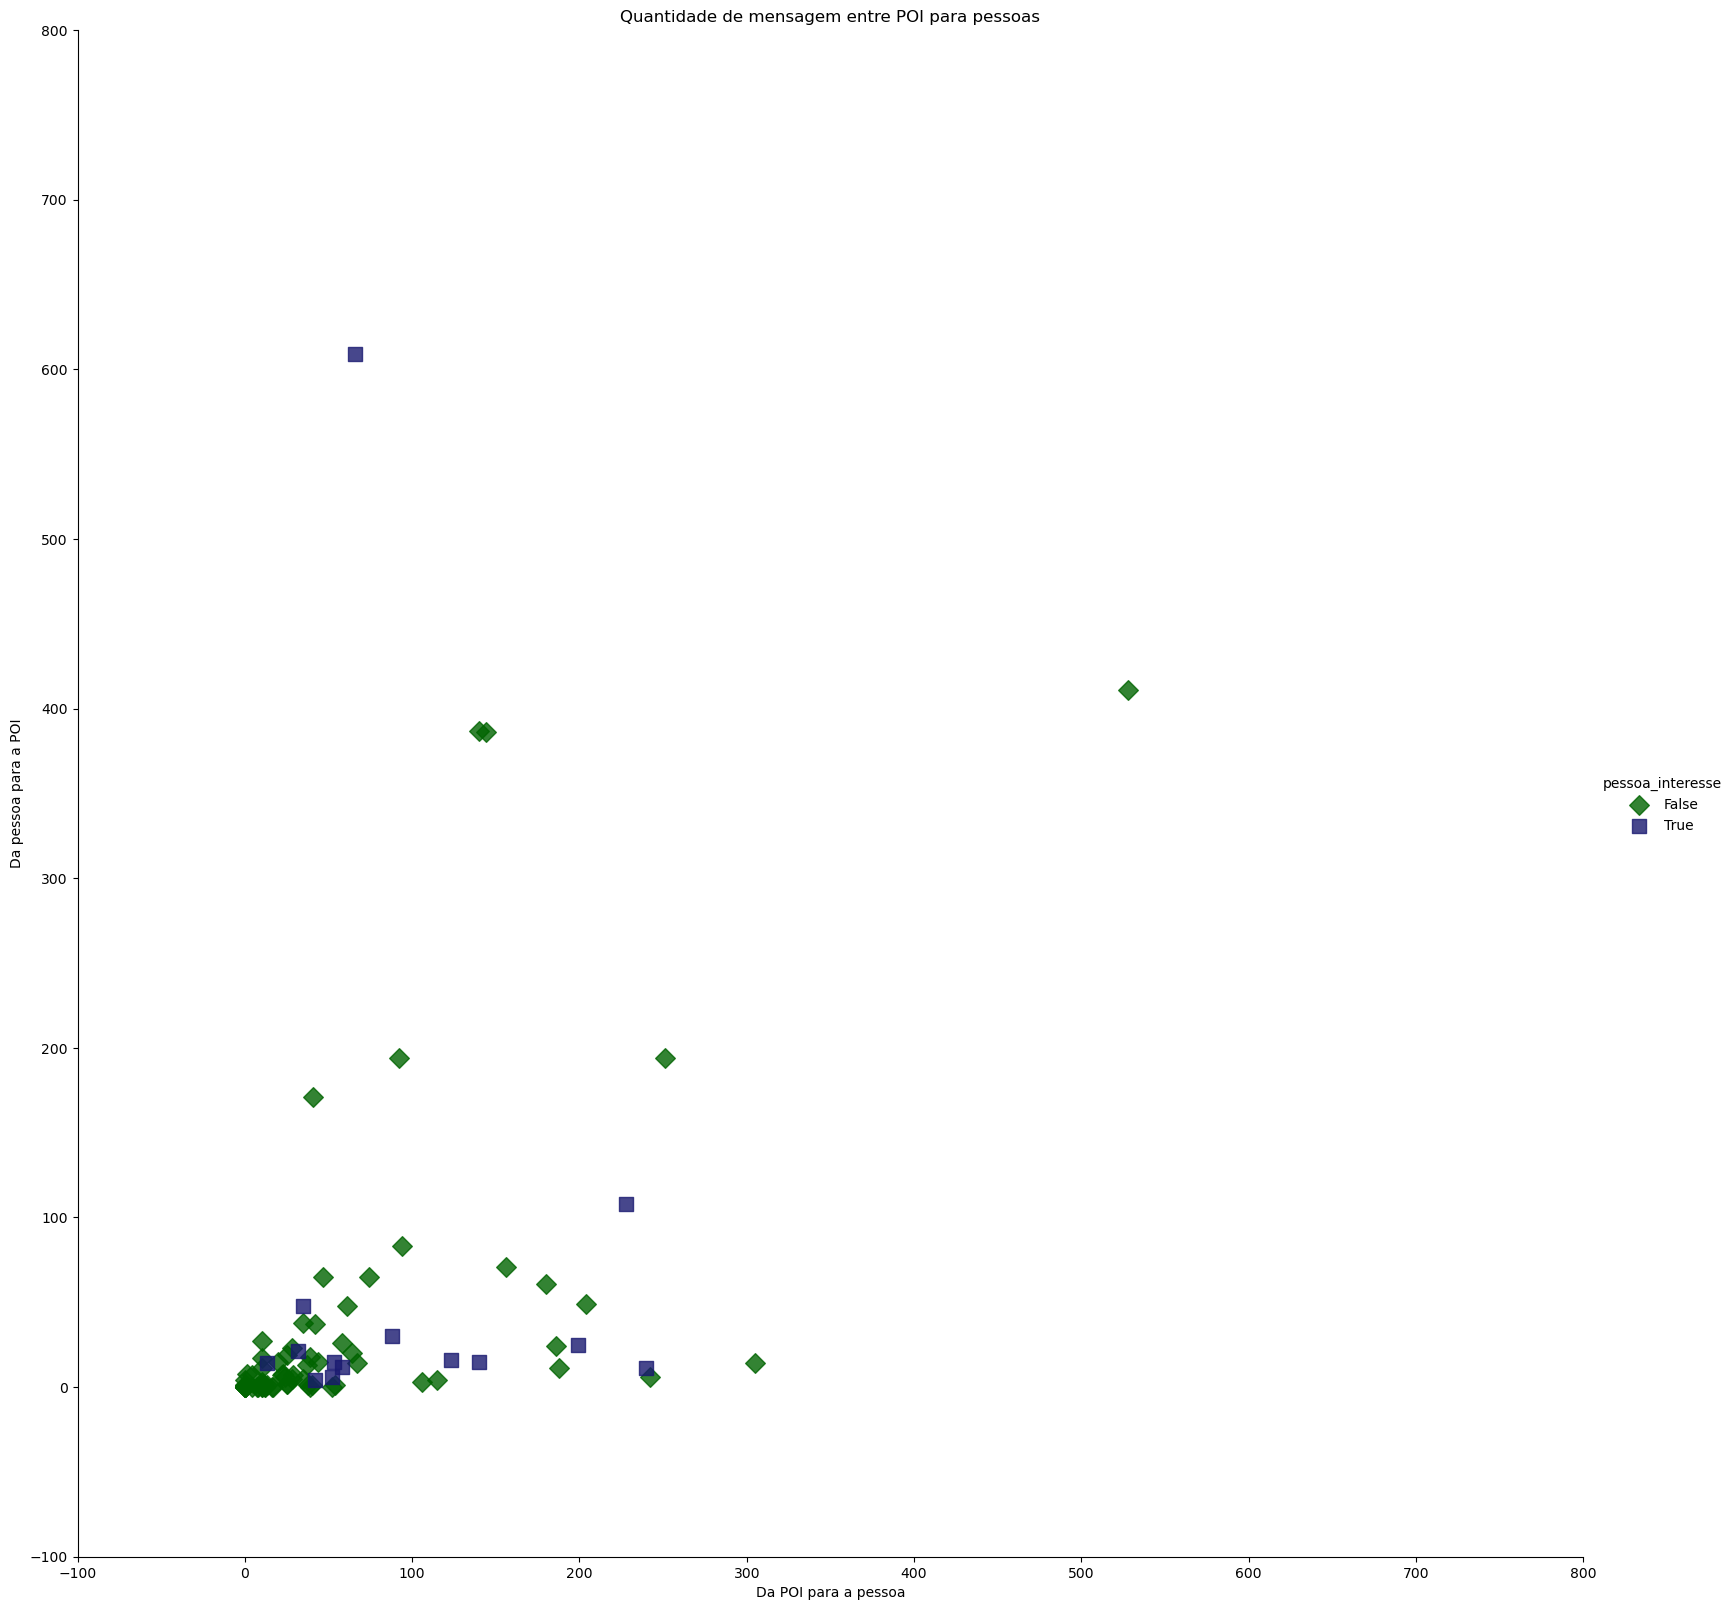

In [28]:
# Remove o titulo do eixo X
# Muda estilo dos marcadores
# Alteração de escala
# Alteração de cor dos marcadores
# Alteração do tamanho dos marcadores
# Aumento da forma do marcador

#marker = {False: "o", True: "s"}
cores = {False: "darkgreen", True: "midnightblue"}

plt.figure(figsize = (24,20))
sns.lmplot(x = 'pessoa_interesse_para_pessoa', y = 'de_pessoa_para_pessoa_interesse', data = df_novo,
          fit_reg = False,
          hue = 'pessoa_interesse',
          markers=["D", ","],
          palette=cores,
          height = 16,
          scatter_kws={'s': 100})

plt.title("Quantidade de mensagem entre POI para pessoas")
plt.ylim(-100, 800)
plt.xlim(-100, 800)
plt.ylabel('Da pessoa para a POI')
plt.xlabel('Da POI para a pessoa')
plt.show()

____________________________________________________________________________________________________________________________________

18) Relação entre o valor do estoque total e o número de estoque restrito, conforme as pessoas de interesse e sem interesse?

<Figure size 1800x1400 with 0 Axes>

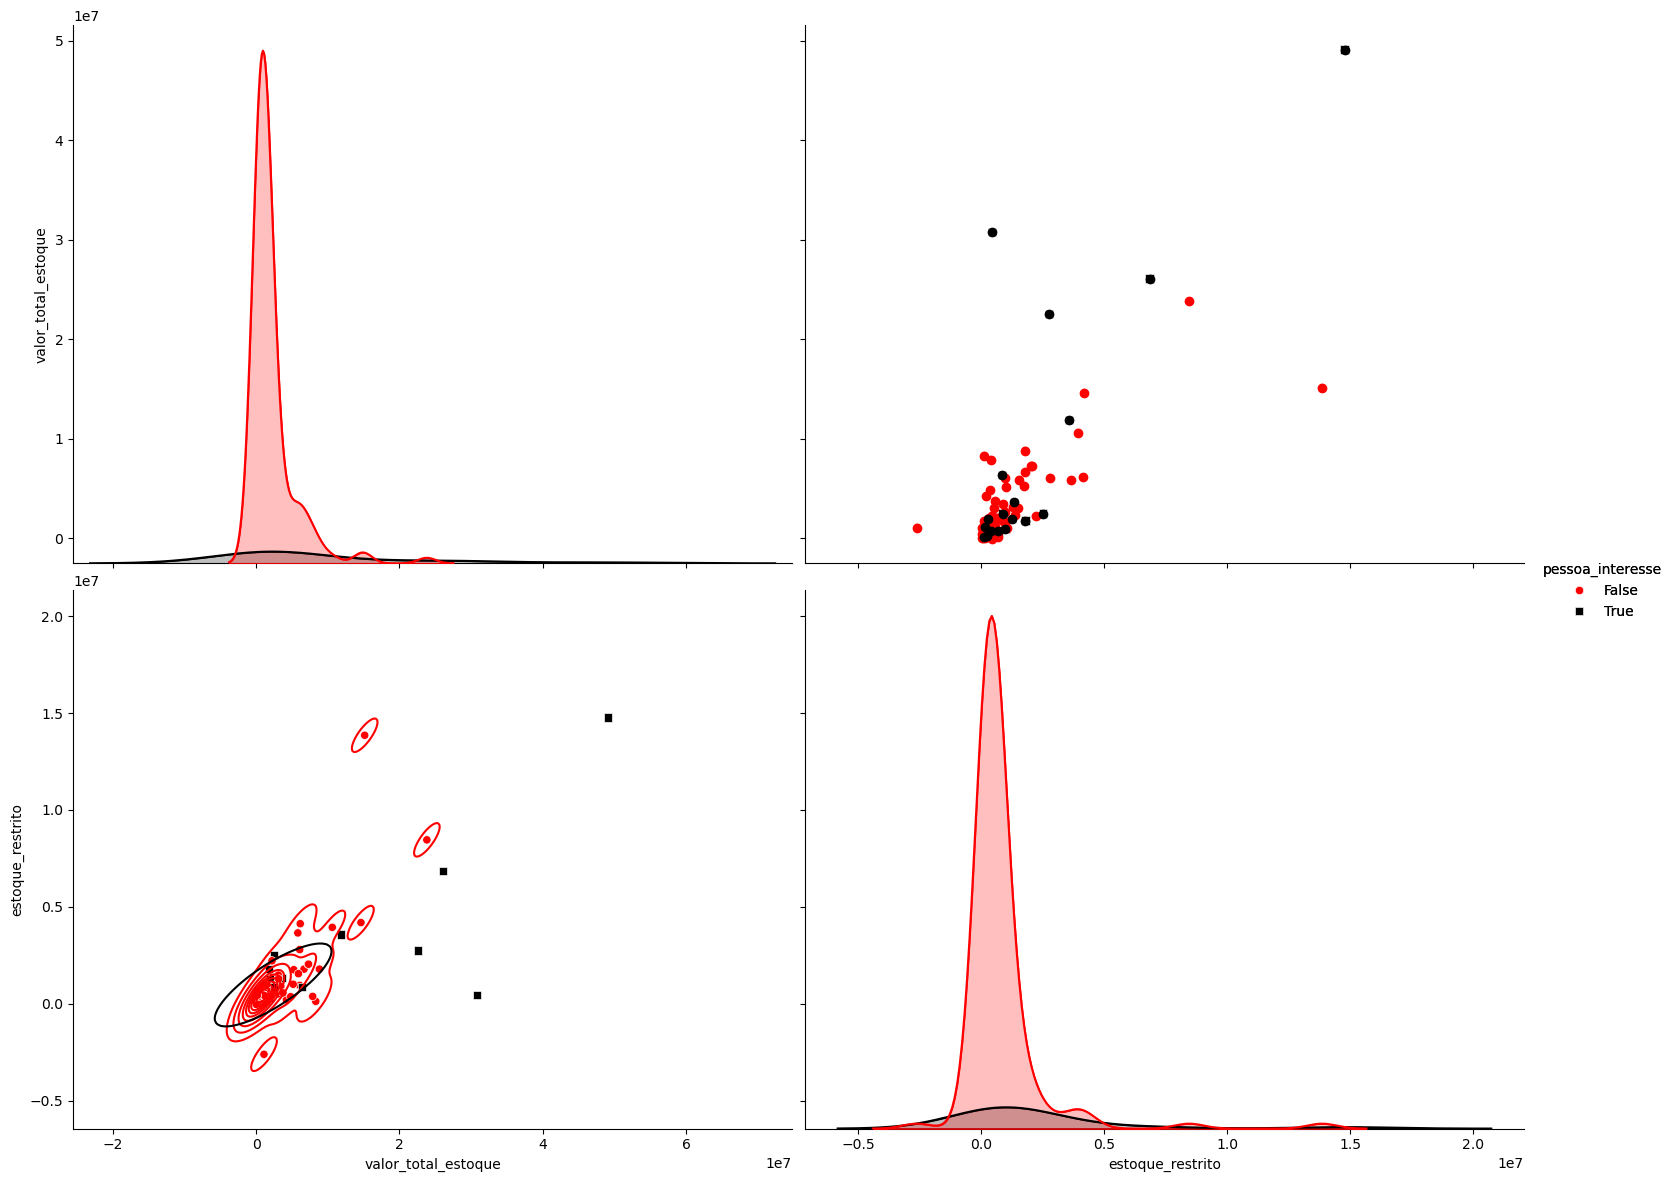

In [65]:
# Muda estilo dos marcadores
# Alteração de escala
# Alteração de cor dos marcadores
# Aumento da forma do marcador
# Aumento do tamanho do gráfico

cores = {False: "red", True: "black"}
marcadores = ["o", "s"]  # ordem: [False, True]

plt.figure(figsize = (18,14))
grid = sns.pairplot(data=df_novo, vars=["valor_total_estoque", "estoque_restrito"], hue="pessoa_interesse",
                   markers=marcadores,
                   palette = cores,
                   height = 6,
                   aspect=1.2)
    
grid = grid.map_upper(plt.scatter)
grid = grid.map_diag(sns.kdeplot)
grid = grid.map_lower(sns.kdeplot).add_legend()

____________________________________________________________________________________________________________________________________

12) Há números acima da média entre despesas, total de pagamentos e o incentivo a longo prazo? 

C:\Users\User\AppData\Local\Temp\ipykernel_21296\521932134.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_filtrado = df_novo[colunas].applymap(lambda x: x if x > 10000 else None)


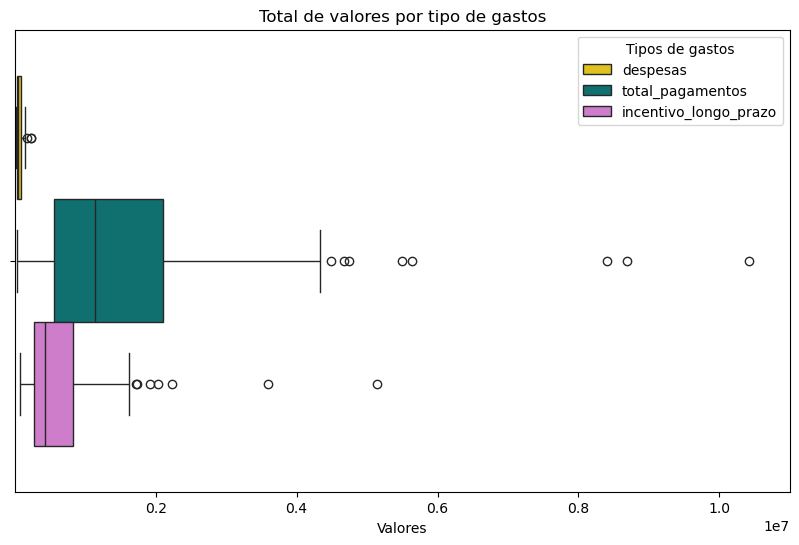

In [26]:
# Alteração de escala
# Alteração de cores dos boxplot's

colunas = ['despesas', 'total_pagamentos', 'incentivo_longo_prazo']

cores = ["gold", "teal", "orchid"]

df_filtrado = df_novo[colunas].applymap(lambda x: x if x > 10000 else None)
df_meltado = df_filtrado.melt(var_name='Tipos de gastos', value_name='Valor').dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_meltado,
            x = 'Valor',
            orient='h',
            palette = cores,
            hue='Tipos de gastos')

plt.title('Total de valores por tipo de gastos')
plt.xlabel('Valores')
plt.xlim(400, 11000000)
plt.show()

____________________________________________________________________________________________________________________________________

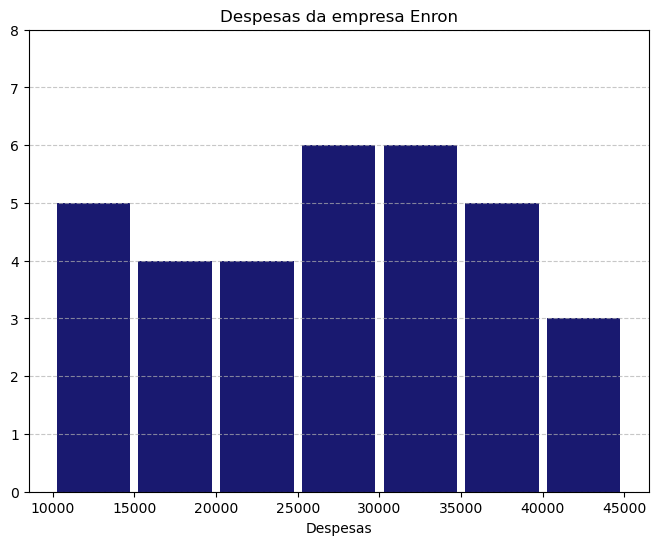

In [67]:
# Alteração de escala do eixo Y
# Alteração de cor das barras

salario = df_novo['despesas']

cores = sns.color_palette("Set2")

plt.figure(figsize = (8,6))
plt.hist(salario, bins=range(10000, 50000, 5000), rwidth=0.9, color="midnightblue")
plt.title('Despesas da empresa Enron')
plt.xlabel('Despesas')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.ylim(-0, 8)
#plt.xlim(-100, 800)

plt.show()

____________________________________________________________________________________________________________________________________

### Feedbacks de colegas

Primeiro feedback feito pela colega ARIELI PAULINO DE SOUZA para o gráfico abaixo:

"Olá Alexandre, boa tarde como vai?  Achei as visualizações boas, mas o que acha de tentar um gráfico de barras no primeiro? Quanto as cores, acredito que colocar mais chamativo ao false, poderia levar mais atenção de quem irá realizar a análise."

Mudança das cores para o segundo gráfico de visualizações efetivas:

<Figure size 2400x2000 with 0 Axes>

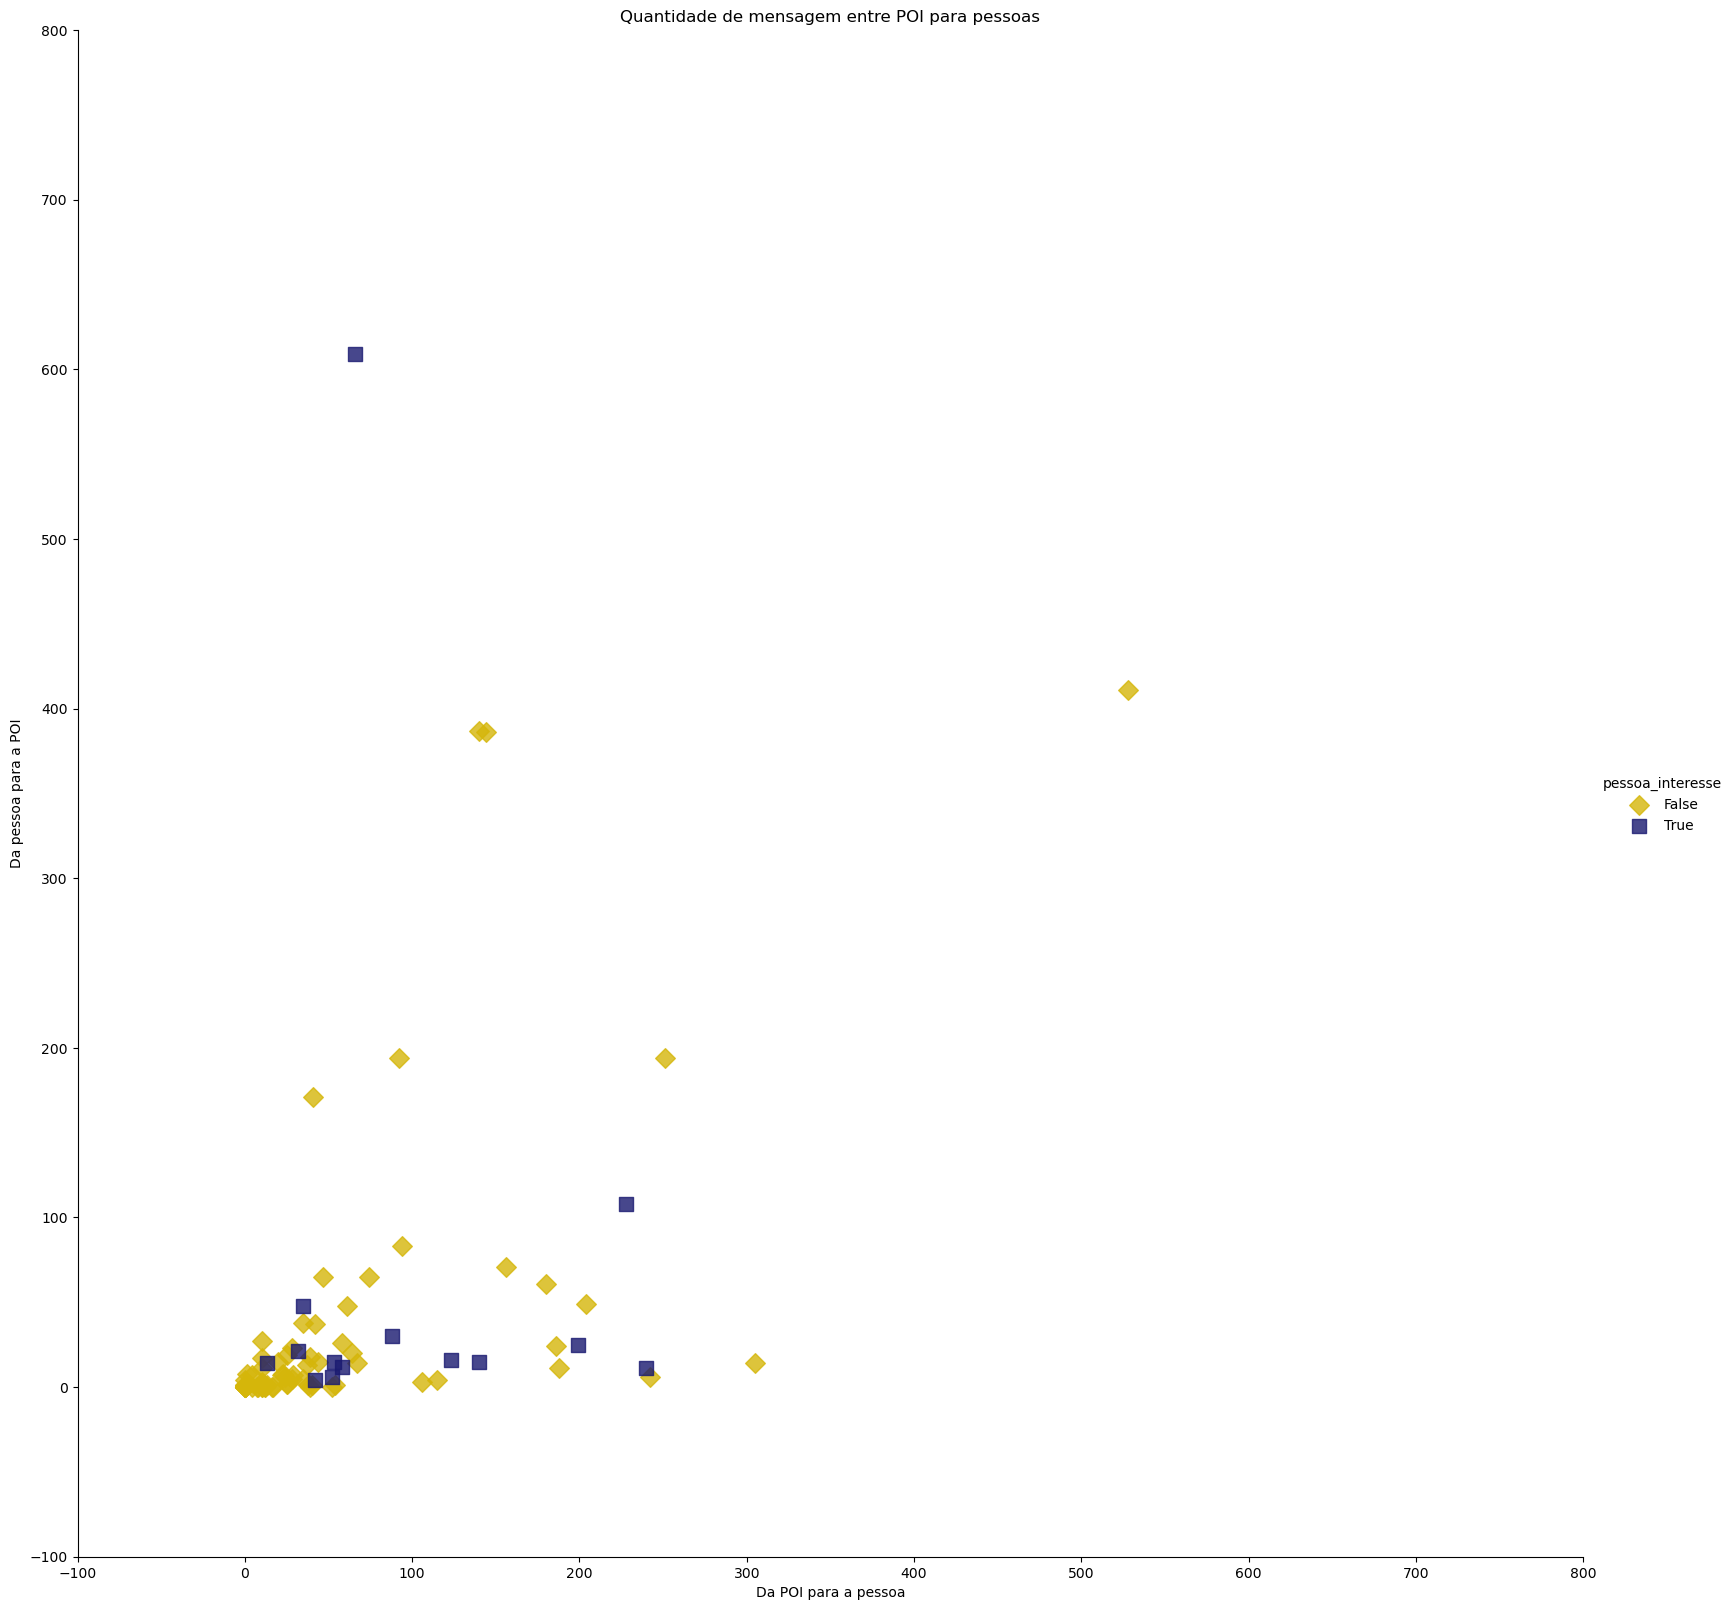

In [32]:
# Remove o titulo do eixo X
# Muda estilo dos marcadores
# Alteração de escala
# Alteração de cor dos marcadores
# Alteração do tamanho dos marcadores
# Aumento da forma do marcador

#marker = {False: "o", True: "s"}
cores = {False: "#d5b60a", True: "midnightblue"}

plt.figure(figsize = (24,20))
sns.lmplot(x = 'pessoa_interesse_para_pessoa', y = 'de_pessoa_para_pessoa_interesse', data = df_novo,
          fit_reg = False,
          hue = 'pessoa_interesse',
          markers=["D", ","],
          palette=cores,
          height = 16,
          scatter_kws={'s': 100})

plt.title("Quantidade de mensagem entre POI para pessoas")
plt.ylim(-100, 800)
plt.xlim(-100, 800)
plt.ylabel('Da pessoa para a POI')
plt.xlabel('Da POI para a pessoa')
plt.show()

A visualização dos pontos ficou mais nítido para diferenciar entre pessoas de interesse e as não-interesse

____________________________________________________________________________________________________________________________________

Segundo comentário feito pelo colega KLEBER MARDEGAN:

"Bom dia Alexandre. Tudo bem? E como ficariam os mesmo gráficos usando o histograma? Acredito que a visualização seria interessante também"

Abaixo o modelo de histograma do primeiro gráfico nas visualizações efetivas, no formato de violino:

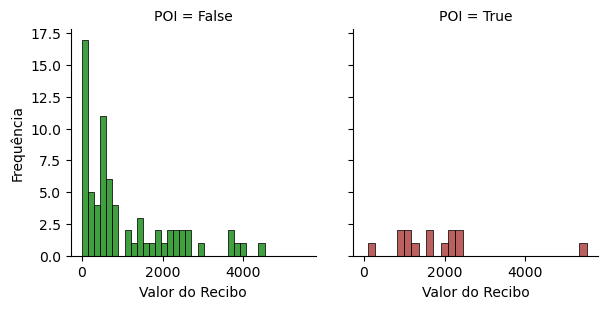

In [37]:
cores = ["green", "brown"]

facet = sns.FacetGrid(df_novo, col="pessoa_interesse")
for ax, color, (key, data) in zip(facet.axes.flat, cores, df_novo.groupby("pessoa_interesse")):
    sns.histplot(data=data, x="recibo_compart_pessoa_interesse", ax=ax, color=color, bins=30, edgecolor="black")
facet.set_titles("POI = {col_name}")
facet.set_axis_labels("Valor do Recibo", "Frequência")

Realmente deixou mais claro a visualização do total dos valores do recibo compartilhado entre pessoas de interesse e não-interesse.

____________________________________________________________________________________________________________________________________

# Conclusão


## Reflexão

Nesta seção você deve apresentar uma reflexão sobre sua atuação neste projeto e sobre os conceitos aprendidos e praticados. A ideia é apresentar (1) o que você fez bem e (2) o que você poderia ter feito diferente. Esta reflexão deve possuir ao menos 2500 caracteres (sem espaços).


```
A partir das atividades que foram propostas neste projeto, acredito que os conceitos aprendidos os que foram bem apresentados foram às pesquisas feitas sobre a base de dados e sobre a própria empresa da Enron, bom aproveitamento dos dados, utilizado variada dos modelos de gráficos das bibliotecas Matplotlib e Seaborn e boa utilização dos detalhamentos nos gráficos para as visualizações efetivas. Sobre o que eu poderia ter feito diferente neste projeto, seria: melhorar as perguntas criadas para uma reposta vinda dos gráficos, usar melhor as variáveis para deixar mais claro a leitura nos gráficos, trabalhar melhor com outras formas de imputação de dados e trabalhar melhor a visualização como escalas, cores dos gráficos.

Pelas pesquisas feitas, foi uma forma de obter um contexto mais abrangente sobre o que aconteceu com a empresa Enron e a origem dos dados. Na utilização dos dados, foi um aproveitamento superior a 90%, com a utilização de quase todas as variáveis, com a necessidade da exclusão de variáveis com valores nulos acima de 70% e com a imputação com a mediana, de variáveis com valores nulos abaixo de 50% assim, obtive um bom aproveitamento dos dados para a criação dos gráficos. Já sobre os gráficos, foi realizada uma boa variação, com a utilização de histogramas, boxplot, kdeplot, gráficos de barras, dispersão, heatmap, violinplot, entre outros. Dessa forma, foi possível criar um relatório grande com diversas formas de visualizar os dados do dataset. Por fim, acredito que os detalhamentos dos gráficos também foi um conceito que aprendi bastante e consegui praticar nos cinco gráficos que adicionei na etapa quatro das visualizações efetivas.

Sobre as práticas que eu poderia ter feito melhor, uma melhora na apresentação de perguntas mais objetivas e com um aprofundamento melhor, para que o gráfico seja mais claro e objetivo. Outro conceito que poderia ser melhor seria a usabilidade das variáveis sendo a maioria, variáveis numéricas dessa forma, pode ser utilizado regressão linear e outros conceitos estatísticos mais avançados, para análises melhores.

O trabalho com outras imputações de dados seria outra forma melhor pra ter trabalhado, pois como foi utilizada a imputação com a mediana das variáveis, seria uma boa a utilização da imputação com a média ou com a moda das variáveis numéricas. Por fim, a prática com as visualizações efetivas poderia ter feito diferente com cores mais nítidas e também mudando até o modelo de gráfico, a fim de uma melhor amostragem dos dados com escalas melhores, com mais detalhamento e mais clareza.

Com os conceitos aprendidos nas unidades de aprendizagem, nas vídeo aulas e nos matérias de pesquisas online, esse relatório foi um ótimo aprendizado de como colocá-los em prática. Acredito que com os trabalhos e conceitos que foram bem feitos, tive uma noção bem abrangente de como trabalhar com gráficos e com dados reais, e também com problemas como trabalhar com valores nulos, e a falta deles no dataset.
```

____________________________________________________________________________________________________________________________________

# Referências

Adicione na célula abaixo todas as referências utilizadas durante a preparação deste relatório.

TIWARI, S. **Enron-Spam**. Disponível em: https://github.com/shantnu/Enron-Spam/tree/master. Acesso em: 12 jun. 2025.

WASKOM M **Seaborn.org**. Disponível em: https://seaborn.pydata.org/index.html. Acesso em: 24 jun. 2025.

HUNTER, J D **Matplotlib**. Disponível em: https://matplotlib.org/. Acesso em: 26 jun. 2025.

CUKIERSKI, W **The Enron Email Dataset**. Disponível em: https://www.kaggle.com/datasets/wcukierski/enron-email-dataset. Acesso em: 12 jun. 2025.

WIKIPEDIA **Enron**. Disponível em: https://en.wikipedia.org/wiki/Enron. Acesso em: 12 de junho de 2025

**Durante a preparação deste relatório, o(s) autor(es) usaram CHATGPT versão 3.5  para auxílio na criação dos gráficos. Após usar essa ferramenta, o(s) autor(es) revisaram e editaram o conteúdo conforme necessário e assumem total responsabilidade pelo conteúdo.**

____________________________________________________________________________________________________________________________________

## Trabalhos futuros

Na célula abaixo, apresente ao menos 3 (três) ideias diferentes que você gostaria de atuar em um trabalho futuro com esta mesma base de dados. Elas podem incluir, por exemplo, o uso de aprendizagem de máquina para um objetivo específico, ou criar/analisar variáveis que não tivemos tempo de fazer durante a execução deste trabalho. 
Você deve fornecer **detalhes** sobre como cada ideia seria abordada, especificando as técnicas e/ou metodologia a ser seguida.
Esta seção deve possuir ao menos 2500 caracteres (sem espaços).

```
Escreva sua resposta aqui.
```


____________________________________________________________________________________________________________________________________

# Último passsos

1. Salve este relatório como um jupyter notebook em formato `.ipynb`
2. Salve uma cópia deste relatório como um arquivo PDF, isto é, com extensão `.pdf`
3. Compacte ambos em um único arquivo com extensão ZIP no seguinte formato:(`analise-enron-primeiro_nome-ultimo_nome.zip`)
4. Envie o seu relatório para avaliação no ambiente virtual de aprendizagem